# Act 06: Backtest orientado a eventos de la estrategia SMA + Bollinger + RSI + MACD (AAPL, 1día)
**Isabela Torres Septien Uribe**

Este notebook toma la estrategia de la Act 05 (`SPEC.md`) y la corre sobre un **motor orientado a eventos** (barra por barra, no vectorizado). Además de repetir el flujo de la Act 05, agrega lo que pide la Act 06:

| # | Requisito de la Act 06 | Dónde está |
|---|---|---|
| 1 | `backtest()` como función pura en `src/backtest.py`, con cash, posición y equity explícitos | Sección 3 y prueba `test_backtest_is_pure` |
| 2 | Golden-file test: camino corto con el equity final calculado a mano | Sección 4 |
| 3 | Prueba de truncamiento del **pipeline completo** (indicadores → señales → combinación → backtest) | Sección 5 |
| 4 | Curva de equity, curva de drawdown, lista de operaciones | Secciones 7 y 8 |
| 5 | Sensibilidad a costos (Sharpe y equity contra costo de ida y vuelta de 0 a 50 bps) | Sección 10 |
| 6 | Métricas en `src/metrics.py`: drawdown máximo, Calmar, turnover, win rate teórico (p\*) contra empírico | Secciones 9 y 11 |
| 7 | Tabla de auditoría de sesgos con evidencia concreta | Sección 12 |

**Parámetros vigentes (los del código, `src/strategy.py`)**

| Bloque | Regla |
|---|---|
| Entrada C1 (tendencia) | SMA_10 > SMA_100 **y** close > BB_mid |
| Entrada C2 (momentum) | MACD > señal **y** 50 < RSI_14 < 70 **y** close < BB_high |
| Disparador | Cruce alcista del MACD sobre su señal con C1 y C2 activas |
| Salidas | SL = entrada − 4 ATR · TP = entrada + 3 ATR · break-even al ganar 1 ATR |
| Sizing | unidades = ρ × equity / (entrada − SL), ρ = 2 %, sin apalancamiento |
| Costos | 10 bps comisión + 5 bps slippage por lado (30 bps ida y vuelta) |
| Capital inicial | $100,000 |

In [1]:
import subprocess, sys
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from src.indicators import load_stock, add_indicators
from src.strategy import Params, entry_conditions
from src.backtest import backtest, run_pipeline, with_costs, scale_costs
from src import metrics as M




In [2]:
import yfinance as yf
d = yf.download("AAPL", start="2021-09-29", end="2026-09-30", auto_adjust=True, progress=False)
d.columns = d.columns.get_level_values(0)
d.index.name = "Date"
d.to_csv("data/AAPL.csv")

In [3]:

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, AQUA, VIOLET, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#8a8984"
GOOD, BAD, WARN = "#008300", "#e34948", "#eda100"
usd = plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
DATA = "data/AAPL.csv"
P = Params()
P

Params(rho=0.02, sl_atr=4.0, tp_atr=3.0, be_atr=1.0, rsi_low=50.0, rsi_high=70.0, commission_bps=10.0, slippage_bps=5.0, initial_cash=100000.0)

## 1. Datos: velas diarias de AAPL y división train / test / validation
Velas diarias descargadas de Yahoo Finance con `yfinance` y `auto_adjust=True`, es decir, precios **ajustados por splits y dividendos** (sin el ajuste, un split se vería como una caída falsa y dispararía el stop). No hay agregación: cada barra es un día hábil de la bolsa de Nueva York (9:30 a 16:00). Se eliminan las filas con NaN.

La división es cronológica, 60 / 20 / 20, y cada tramo arranca con $100,000.

In [4]:
df = load_stock(DATA)
n = len(df); a, b = int(n * 0.6), int(n * 0.8)
splits = {"Train": df.iloc[:a], "Test": df.iloc[a:b], "Validation": df.iloc[b:]}
tabla_split = pd.DataFrame({k: {"Inicio": v.index[0], "Fin": v.index[-1], "Barras": len(v),
                                "Precio inicial": v["close"].iloc[0], "Precio final": v["close"].iloc[-1],
                                "Buy & hold (%)": 100 * (v["close"].iloc[-1] / v["close"].iloc[0] - 1)}
                            for k, v in splits.items()}).T
print(f"Barras de 1 d: {len(df):,}  |  {df.index[0]}  ->  {df.index[-1]}")
tabla_split

Barras de 1 d: 1,255  |  2021-09-29 00:00:00  ->  2026-09-29 00:00:00


,Inicio,Fin,Barras,Precio inicial,Precio final,Buy & hold (%)
Train,2021-09-29 00:00:00,2024-09-26 00:00:00,753,139.31,225.63,61.96
Test,2024-09-27 00:00:00,2025-09-29 00:00:00,251,225.90,253.49,12.21
Validation,2025-09-30 00:00:00,2026-09-29 00:00:00,251,253.69,329.40,29.84


## 2. Pipeline: indicadores → señales → combinación
`run_pipeline()` encadena las tres etapas y entrega el resultado al motor de backtest. Todo es causal: cada valor en *t* solo usa datos hasta *t*.

In [5]:
ind = add_indicators(df)
sig = entry_conditions(ind, P)
data = ind.join(sig)
conteo = pd.DataFrame({"Barras": [sig["c1_tendencia"].sum(), sig["c2_momentum"].sum(),
                                  sig["entry_signal"].sum(), sig["entry_trigger"].sum()]},
                      index=["C1 tendencia", "C2 momentum", "Señal (C1 y C2)", "Disparador (cruce MACD)"])
conteo["% de las barras"] = 100 * conteo["Barras"] / len(sig)
conteo

,Barras,% de las barras
C1 tendencia,484,38.57
C2 momentum,345,27.49
Señal (C1 y C2),212,16.89
Disparador (cruce MACD),14,1.12


## 3. Motor orientado a eventos: `backtest()` como función pura

El motor recorre las barras **una por una** y mantiene tres variables de estado explícitas: `cash`, `pos` (la posición abierta o `None`) y `equity`. En cada barra *i* hace, en este orden:

| Paso | Qué hace | Por qué en ese orden |
|---|---|---|
| 1. Ejecutar orden pendiente | Si en *i−1* hubo disparador, compra al **open** de *i* × (1 + slippage). SL/TP con el ATR de *i−1*. Descuenta del cash el nocional y la comisión. | La señal se conoce al cierre de *i−1*; lo primero que se puede operar es el open de *i*. |
| 2. Revisar salidas | Gap bajo el stop → sale al open; si no, stop antes que TP (empate → stop). | No se conoce el orden de high y low dentro de la barra: supuesto conservador. |
| 3. Break-even | Si no salió y el high alcanza entrada + 1 ATR, el stop sube a la entrada **desde la siguiente barra**. | Evita usar el high de la barra para mover un stop que se evalúa en la misma barra. |
| 4. Marcar a mercado | `equity = cash + unidades × close` | El equity de *i* es el que usa el sizing de la siguiente entrada. |
| 5. Leer señal al cierre | Si no hay posición y `entry_trigger[i]`, deja una orden para *i+1*. | Una sola posición a la vez; señales con posición abierta se ignoran. |

**Función pura:** `backtest(data, params)` no lee variables globales, no escribe archivos y no modifica `data`; con la misma entrada siempre regresa lo mismo (`test_backtest_is_pure`). La posición es un objeto local que vive solo dentro del ciclo.

**Con velas diarias** una barra es un día: la señal se lee al cierre del día *t* y la compra se hace en la apertura del siguiente día hábil. Entre las dos pasa la noche, así que el precio de entrada puede abrir con gap respecto a la señal (el motor lo toma en cuenta porque usa el open real).

In [6]:
res = backtest(data, P)
eq, trades = res["equity"], res["trades"]
print("Estado explícito que guarda el motor en cada barra (primeras y últimas filas):")
display(eq.head(3)); display(eq.tail(3))

# Verificación de pureza sobre los datos reales
copia = data.copy(deep=True)
res_b = backtest(data, P)
print("¿data quedó intacta?        ", data.equals(copia))
print("¿resultado determinista?    ", res_b["equity"].equals(eq) and res_b["trades"].equals(trades))

Estado explícito que guarda el motor en cada barra (primeras y últimas filas):


,cash,units,equity,en_posicion
datetime,,,,
2021-09-29,"100,000.00",0.00,"100,000.00",False
2021-09-30,"100,000.00",0.00,"100,000.00",False
2021-10-01,"100,000.00",0.00,"100,000.00",False


,cash,units,equity,en_posicion
datetime,,,,
2026-09-25,"105,115.62",0.00,"105,115.62",False
2026-09-28,"105,115.62",0.00,"105,115.62",False
2026-09-29,"105,115.62",0.00,"105,115.62",False


¿data quedó intacta?         True
¿resultado determinista?     True


### 3.1 Traza del estado durante una operación
Operación 2 de la lista: de la barra de la señal a la barra siguiente a la salida. Se ve cómo cambian `cash`, `units` y `equity` en cada evento.

In [7]:
op = trades.iloc[1]
i0 = data.index.get_loc(op["entrada"]) - 1          # barra de la señal
i1 = data.index.get_loc(op["salida"]) + 2
traza = data.iloc[i0:i1][["open", "high", "low", "close", "atr_14", "entry_trigger"]].join(eq)
evento = pd.Series("", index=traza.index)
evento.iloc[0] = "señal al cierre"
evento[op["entrada"]] = f"entra al open ({op['precio_entrada']:,.2f})"
evento[op["salida"]] = f"sale por {op['motivo']} ({op['precio_salida']:,.2f})"
traza["evento"] = evento
print(f"SL = {op['stop_inicial']:,.2f}   TP = {op['take_profit']:,.2f}   unidades = {op['unidades']:.4f}")
traza

SL = 151.77   TP = 172.31   unidades = 170.3352


,open,high,low,close,atr_14,entry_trigger,cash,units,equity,en_posicion,evento
Date,,,,,,,,,,,
2023-04-19,163.14,165.46,162.89,164.94,2.93,True,"99,946.75",0.00,"99,946.75",False,señal al cierre
2023-04-20,163.43,165.18,162.91,163.98,2.89,False,"72,067.68",170.34,"99,998.84",True,entra al open (163.51)
2023-04-21,162.40,163.78,161.85,162.37,2.83,False,"72,067.68",170.34,"99,725.64",True,
2023-04-24,162.35,162.94,161.26,162.68,2.75,False,"72,067.68",170.34,"99,777.60",True,
2023-04-25,162.54,163.64,161.10,161.14,2.74,False,"72,067.68",170.34,"99,516.14",True,
2023-04-26,160.45,162.63,160.19,161.13,2.71,False,"72,067.68",170.34,"99,514.46",True,
2023-04-27,162.54,165.86,162.54,165.71,2.86,False,"72,067.68",170.34,"100,293.82",True,
2023-04-28,165.79,167.13,165.19,166.96,2.79,False,"72,067.68",170.34,"100,506.67",True,
2023-05-01,166.57,167.72,165.94,166.87,2.72,True,"72,067.68",170.34,"100,491.59",True,


## 4. Golden-file test: equity calculado a mano

Un golden-file test fija un camino corto de pocas barras y compara el resultado del código contra números calculados **en papel**, sin correr el código que se está probando. Si alguien cambia el motor y altera la contabilidad, el test falla.

Se usan cuatro caminos (todos con ATR = 10, SL = 4 ATR, TP = 3 ATR, BE = 1 ATR, ρ = 2 %). El más completo es el **camino 4**:

| Barra | open | high | low | close | Señal | Evento (cálculo a mano) | Cash | Equity |
|---|---|---|---|---|---|---|---|---|
| b0 | 100 | 101 | 99 | 100 | ✔ | Señal al cierre | 100,000.00 | 100,000.00 |
| b1 | 100 | 104 | 96 | 100 | ✔ (ignorada) | Entra en 100 · SL 60 · TP 130 · u = 0.02·100,000/40 = **50** · comisión 50·100·0.001 = 5 | 94,995.00 | 94,995 + 50·100 = **99,995.00** |
| b2 | 50 | 52 | 48 | 50 | ✔ | **Gap**: abre en 50 ≤ 60 → sale al open 50 · comisión 2.5 · PnL = 50·(−50) − 7.5 = −2,507.5 | 97,492.50 | **97,492.50** |
| b3 | 50 | 55 | 49 | 54 | | Entra en 50 · SL 10 · TP 80 · u = 0.02·97,492.5/40 = **48.74625** · comisión 2.4373125 | 95,052.7501875 | + 48.74625·54 = **97,685.0476875** |
| b4 | 54 | 61 | 53 | 60 | | high 61 ≥ 60 → **break-even** (stop a 50 desde b5) | 95,052.7501875 | + 48.74625·60 = **97,977.5251875** |
| b5 | 85 | 90 | 84 | 88 | | **Gap**: abre en 85 ≥ 80 → sale al open 85 · comisión 4.14343125 · PnL = 1,699.53800625 | 99,192.03800625 | **99,192.03800625** |
| b6 | 88 | 89 | 87 | 88 | | Sin posición | 99,192.03800625 | **99,192.03800625** |

Comprueba al mismo tiempo: sizing con el equity actualizado (interés compuesto), señal ignorada con posición abierta, salida por gap abajo del stop, salida por gap arriba del TP y activación del break-even.

El **camino 3** usa los costos completos del SPEC (10 bps + 5 bps de slippage): fill = 100 × 1.0005 = 100.05, SL = 60.05, sale en 60.05 × 0.9995 = 60.019975, PnL = −2,009.50474875 y equity final = **97,990.49525125**. La pérdida antes de costos es exactamente ρ × equity = $2,000.

In [8]:
def make_bars(rows, atr=10.0):
    idx = pd.date_range("2024-01-01", periods=len(rows), freq="1h")
    d = pd.DataFrame(rows, columns=["open", "high", "low", "close", "entry_trigger"], index=idx)
    d["atr_14"] = atr
    return d

caminos = {
    "1. Take-profit (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 131, 109, 125, False), (125, 126, 124, 125, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 + 50 * 30 - 5 - 6.5),
    "2. Break-even (10 bps, sin slippage)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 102, False), (102, 112, 101, 110, False),
         (110, 111, 99, 100, False), (100, 101, 99, 100, False)],
        Params(commission_bps=10, slippage_bps=0), 100_000 - 5 - 5),
    "3. Stop-loss con costos del SPEC (10 + 5 bps)": (
        [(100, 101, 99, 100, True), (100, 105, 95, 100, False), (100, 102, 55, 58, False), (58, 59, 57, 58, False)],
        Params(), 97_990.49525125),
    "4. Dos operaciones: gaps, compuesto y break-even": (
        [(100, 101, 99, 100, True), (100, 104, 96, 100, True), (50, 52, 48, 50, True), (50, 55, 49, 54, False),
         (54, 61, 53, 60, False), (85, 90, 84, 88, False), (88, 89, 87, 88, False)],
        Params(commission_bps=10, slippage_bps=0), 99_192.03800625),
}
gold = []
for nombre, (rows, prm, esperado) in caminos.items():
    r = backtest(make_bars(rows), prm)
    obtenido = r["equity"]["equity"].iloc[-1]
    gold.append({"Camino": nombre, "Equity a mano ($)": esperado, "Equity del código ($)": obtenido,
                 "Diferencia ($)": obtenido - esperado, "Salidas": ", ".join(r["trades"]["motivo"]),
                 "Resultado": "PASA" if abs(obtenido - esperado) < 1e-6 else "FALLA"})
gold = pd.DataFrame(gold).set_index("Camino")
pd.options.display.float_format = lambda x: f"{x:,.8f}" if abs(x) < 1 else f"{x:,.4f}"
display(gold)
pd.options.display.float_format = lambda x: f"{x:,.2f}"

,Equity a mano ($),Equity del código ($),Diferencia ($),Salidas,Resultado
Camino,,,,,
"1. Take-profit (10 bps, sin slippage)","101,488.5000","101,488.5000",0.00000000,take_profit,PASA
"2. Break-even (10 bps, sin slippage)","99,990.0000","99,990.0000",0.00000000,break_even,PASA
3. Stop-loss con costos del SPEC (10 + 5 bps),"97,990.4953","97,990.4953",0.00000000,stop_loss,PASA
"4. Dos operaciones: gaps, compuesto y break-even","99,192.0380","99,192.0380",0.00000000,"stop_loss, take_profit",PASA


,Equity a mano,Equity código,Cash código,Unidades,Diferencia
b0,"100,000.00","100,000.00","100,000.00",0.00,0.00
b1,"99,995.00","99,995.00","94,995.00",50.00,0.00
b2,"97,492.50","97,492.50","97,492.50",0.00,0.00
b3,"97,685.05","97,685.05","95,052.75",48.75,0.00
b4,"97,977.53","97,977.53","95,052.75",48.75,0.00
b5,"99,192.04","99,192.04","99,192.04",0.00,0.00
b6,"99,192.04","99,192.04","99,192.04",0.00,0.00


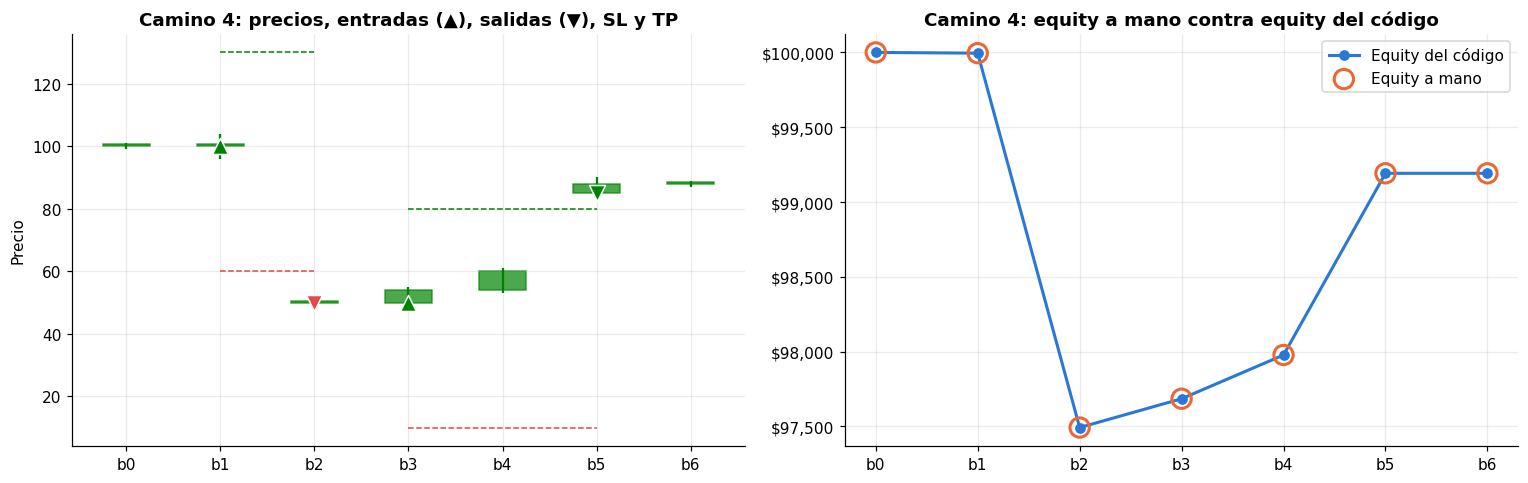

In [9]:
# Camino 4 barra por barra: equity a mano contra equity del código
rows4, prm4, _ = caminos["4. Dos operaciones: gaps, compuesto y break-even"]
b4 = make_bars(rows4); r4 = backtest(b4, prm4)
a_mano = [100_000.0, 99_995.0, 97_492.5, 97_685.0476875, 97_977.5251875, 99_192.03800625, 99_192.03800625]
comp4 = pd.DataFrame({"Equity a mano": a_mano, "Equity código": r4["equity"]["equity"].to_numpy(),
                      "Cash código": r4["equity"]["cash"].to_numpy(), "Unidades": r4["equity"]["units"].to_numpy()},
                     index=[f"b{i}" for i in range(len(a_mano))])
comp4["Diferencia"] = comp4["Equity código"] - comp4["Equity a mano"]
display(comp4)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(b4))
for i, (o_, h_, l_, c_) in enumerate(b4[["open", "high", "low", "close"]].to_numpy()):
    colr = GOOD if c_ >= o_ else BAD
    axs[0].vlines(i, l_, h_, color=colr, lw=1.5)
    axs[0].add_patch(plt.Rectangle((i - 0.25, min(o_, c_)), 0.5, max(abs(c_ - o_), 0.6), color=colr, alpha=0.7))
t4 = r4["trades"]
for _, t in t4.iterrows():
    ie, ix = b4.index.get_loc(t["entrada"]), b4.index.get_loc(t["salida"])
    axs[0].scatter(ie, t["precio_entrada"], marker="^", s=110, color=GOOD, edgecolor="white", zorder=5)
    axs[0].scatter(ix, t["precio_salida"], marker="v", s=110, color=BAD if t["pnl"] < 0 else GOOD, edgecolor="white", zorder=5)
    axs[0].hlines([t["stop_inicial"], t["take_profit"]], ie, ix, colors=[BAD, GOOD], linestyles="--", lw=1)
axs[0].set_xticks(x, [f"b{i}" for i in x]); axs[0].set_title("Camino 4: precios, entradas (▲), salidas (▼), SL y TP")
axs[0].set_ylabel("Precio")
axs[1].plot(x, comp4["Equity código"], color=BLUE, lw=2, marker="o", label="Equity del código")
axs[1].scatter(x, comp4["Equity a mano"], s=160, facecolors="none", edgecolors=ORANGE, lw=2, label="Equity a mano", zorder=5)
axs[1].set_xticks(x, [f"b{i}" for i in x]); axs[1].yaxis.set_major_formatter(usd)
axs[1].set_title("Camino 4: equity a mano contra equity del código"); axs[1].legend()
plt.tight_layout(); plt.show()

## 5. Prueba de truncamiento del pipeline completo

Si en algún punto del pipeline se usara información del futuro, el valor en *t* cambiaría al quitar las barras posteriores. La prueba recalcula **todo** (indicadores → señales → combinación → backtest) sobre `df.iloc[:t+1]` y exige que el valor en *t* sea idéntico al de la corrida completa: indicadores, condiciones C1/C2, señal, disparador, cash, unidades y equity.

Primero los tres puntos de `test_pipeline_truncation` y después un barrido de 40 fechas repartidas en toda la muestra **más** la barra a la mitad de cada una de las 17 operaciones (para probar también el estado con posición abierta).

In [10]:
COLS = ["sma_10", "sma_100", "rsi_14", "macd", "macd_signal", "bb_mid", "bb_high", "atr_14",
        "c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]
full = run_pipeline(df, P)

def trunc_check(t):
    part = run_pipeline(df.iloc[:t + 1], P)
    f = full["data"][COLS].iloc[t]; p = part["data"][COLS].iloc[-1]
    fe = full["equity"].iloc[t]; pe = part["equity"].iloc[-1]
    num = [c for c in COLS if c not in ("c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger")]
    dif_ind = np.nanmax(np.abs(f[num].astype(float).to_numpy() - p[num].astype(float).to_numpy()))
    return {"t": t, "fecha": df.index[t],
            "máx |dif| indicadores": dif_ind,
            "señales iguales": bool((f[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]] ==
                                     p[["c1_tendencia", "c2_momentum", "entry_signal", "entry_trigger"]]).all()),
            "equity completo": fe["equity"], "equity truncado": pe["equity"],
            "|dif| equity": abs(fe["equity"] - pe["equity"]),
            "en posición": bool(fe["en_posicion"])}

display(pd.DataFrame([trunc_check(t) for t in [300, 700, 1100]]).set_index("t"))

,fecha,máx |dif| indicadores,señales iguales,equity completo,equity truncado,|dif| equity,en posición
t,,,,,,,
300,2022-12-07,0.00,True,"100,000.00","100,000.00",0.00,False
700,2024-07-15,0.00,True,"100,917.22","100,917.22",0.00,False
1100,2026-02-18,0.00,True,"103,665.47","103,665.47",0.00,False


Fechas probadas: 52  |  de las cuales 15 con posición abierta
Máxima diferencia en indicadores: 0.00e+00
Máxima diferencia en equity:      0.00e+00
Señales idénticas en todas:       True


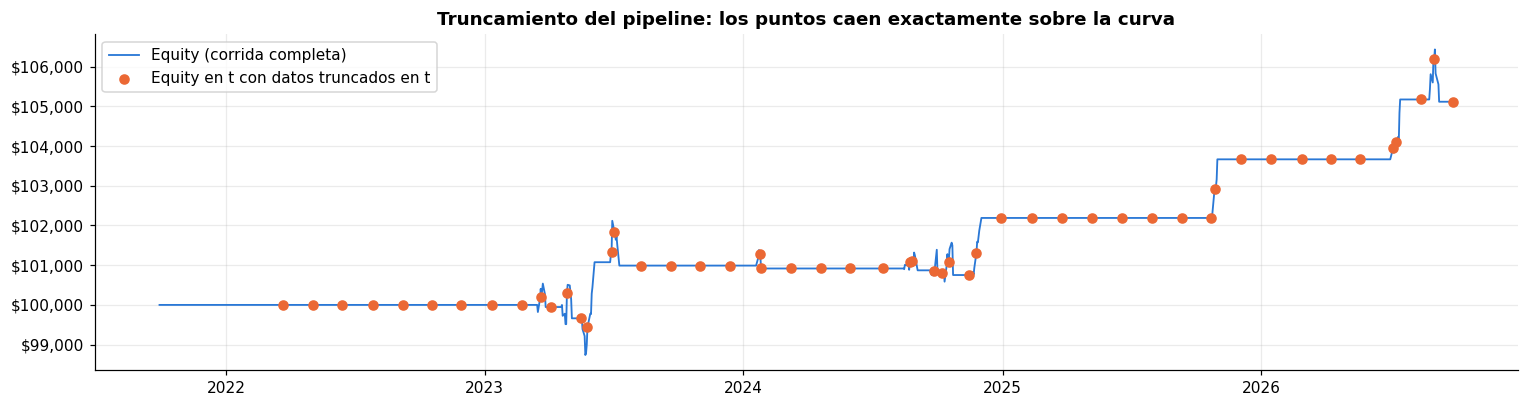

In [11]:
ts_rej = np.linspace(120, len(df) - 2, 40).astype(int)
ts_ops = [(df.index.get_loc(t["entrada"]) + df.index.get_loc(t["salida"])) // 2 for _, t in trades.iterrows()]
ts = np.unique(np.r_[ts_rej, ts_ops])   # 40 fechas repartidas + la barra a la mitad de cada operación
barrido = pd.DataFrame([trunc_check(t) for t in ts]).set_index("t")
print(f"Fechas probadas: {len(barrido)}  |  de las cuales {barrido['en posición'].sum()} con posición abierta")
print(f"Máxima diferencia en indicadores: {barrido['máx |dif| indicadores'].max():.2e}")
print(f"Máxima diferencia en equity:      {barrido['|dif| equity'].max():.2e}")
print(f"Señales idénticas en todas:       {barrido['señales iguales'].all()}")

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(full["equity"].index, full["equity"]["equity"], color=BLUE, lw=1.2, label="Equity (corrida completa)")
ax.scatter(barrido["fecha"], barrido["equity truncado"], color=ORANGE, s=35, zorder=5, label="Equity en t con datos truncados en t")
ax.yaxis.set_major_formatter(usd); ax.set_title("Truncamiento del pipeline: los puntos caen exactamente sobre la curva")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 6. Suite de pruebas (`tests/test_strategy.py`)
Incluye las pruebas de la Act 05 y las nuevas de la Act 06: los golden-file de stop-loss con slippage y de dos operaciones, la pureza de `backtest()`, la mezcla de costos de la curva de sensibilidad, el drawdown máximo calculado a mano, las fórmulas de p\* y el truncamiento del pipeline (que ahora también compara las operaciones cerradas hasta *t*).

In [12]:
out = subprocess.run([sys.executable, "-m", "pytest", "-v", "--color=no", "-p", "no:cacheprovider", "tests"],
                     capture_output=True, text=True)
print(out.stdout[out.stdout.find("collected"):][-3500:])

tems

tests/test_optimize.py::test_theta_to_params_only_changes_exits PASSED   [  4%]
tests/test_optimize.py::test_objective_is_calmar_of_backtest PASSED      [  8%]
tests/test_optimize.py::test_objective_penalizes_too_few_trades PASSED   [ 12%]
tests/test_optimize.py::test_objective_uses_drawdown_floor PASSED        [ 16%]
tests/test_optimize.py::test_forward_chaining_folds_are_ordered_and_disjoint PASSED [ 20%]
tests/test_optimize.py::test_random_walk_keeps_bar_shape_and_breaks_order PASSED [ 25%]
tests/test_strategy.py::test_same_bar_stop_and_target_closes_as_stop PASSED [ 29%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-30000-29500-0.02] PASSED [ 33%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[100000-100-85-0.02] PASSED [ 37%]
tests/test_strategy.py::test_sizing_returns_exact_risk_budget[57321.4-42310.0-42014.87-0.01] PASSED [ 41%]
tests/test_strategy.py::test_never_two_open_positions PASSED             [ 45%]
tests/test_strategy.py::test

## 7. Resultados del backtest: lista de operaciones

In [13]:
cols = ["entrada", "salida", "precio_entrada", "precio_salida", "stop_inicial", "take_profit",
        "unidades", "nocional", "costos", "pnl", "retorno_%", "R", "motivo", "barras"]
tabla_ops = trades[cols].copy()
tabla_ops.index = range(1, len(tabla_ops) + 1); tabla_ops.index.name = "Operación"
tabla_ops.to_csv("operaciones.csv")
print(f"{len(tabla_ops)} operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: "
      f"{'sí' if res['open_position'] else 'ninguna'}")
tabla_ops.style.format({"precio_entrada": "{:,.2f}", "precio_salida": "{:,.2f}", "stop_inicial": "{:,.2f}",
                        "take_profit": "{:,.2f}", "unidades": "{:.4f}", "nocional": "${:,.0f}", "costos": "${:,.2f}",
                        "pnl": "${:,.2f}", "retorno_%": "{:+.2f}%", "R": "{:+.3f}"}) \
    .map(lambda v: f"color: {GOOD}" if isinstance(v, (int, float)) and v > 0 else (f"color: {BAD}" if isinstance(v, (int, float)) and v < 0 else ""),
         subset=["pnl", "R"])

12 operaciones cerradas (guardadas en operaciones.csv).  Posición abierta al final: ninguna


,entrada,salida,precio_entrada,precio_salida,stop_inicial,take_profit,unidades,nocional,costos,pnl,retorno_%,R,motivo,barras
Operación,,,,,,,,,,,,,,
1,2023-03-17 00:00:00,2023-03-28 00:00:00,153.65,153.58,139.23,164.47,138.6417,"$21,303",$42.60,$-53.25,-0.25%,-0.027,break_even,8
2,2023-04-20 00:00:00,2023-05-04 00:00:00,163.51,162.16,151.77,172.31,170.3352,"$27,851",$55.47,$-284.34,-1.02%,-0.142,break_even,11
3,2023-05-19 00:00:00,2023-06-05 00:00:00,173.89,181.92,163.06,182.01,184.0966,"$32,012",$65.50,"$1,412.68",+4.41%,+0.709,take_profit,11
4,2023-06-28 00:00:00,2023-07-10 00:00:00,185.26,185.17,174.27,193.51,183.9040,"$34,071",$68.12,$-85.16,-0.25%,-0.042,break_even,8
5,2024-01-22 00:00:00,2024-01-26 00:00:00,190.08,189.98,176.88,199.98,153.0456,"$29,091",$58.17,$-72.71,-0.25%,-0.036,break_even,5
6,2024-08-15 00:00:00,2024-09-03 00:00:00,222.85,222.74,198.65,240.99,83.4173,"$18,589",$37.17,$-46.46,-0.25%,-0.023,break_even,13
7,2024-09-23 00:00:00,2024-10-01 00:00:00,225.57,225.45,205.01,240.98,98.1524,"$22,140",$44.27,$-55.34,-0.25%,-0.027,break_even,7
8,2024-10-11 00:00:00,2024-10-23 00:00:00,227.51,227.40,209.33,241.15,110.9134,"$25,234",$50.46,$-63.07,-0.25%,-0.031,break_even,9
9,2024-11-20 00:00:00,2024-12-02 00:00:00,226.53,238.33,210.63,238.45,126.7687,"$28,717",$58.93,"$1,437.24",+5.00%,+0.713,take_profit,8


,Operaciones,PnL_total,PnL_promedio,R_promedio,Holding_prom_barras,Costos,% de operaciones
motivo,,,,,,,
take_profit,4.00,"5,832.85","1,458.21",0.72,8.50,215.45,33.33
break_even,8.00,-717.23,-89.65,-0.04,8.75,401.77,66.67
stop_loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN


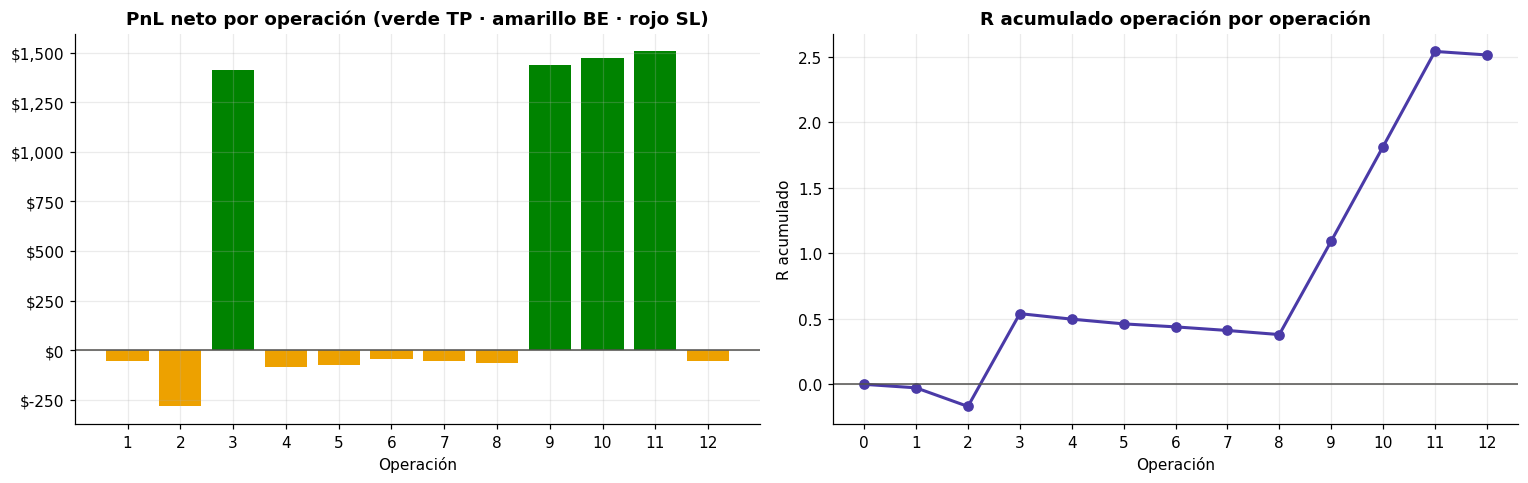

In [14]:
por_motivo = trades.groupby("motivo").agg(Operaciones=("pnl", "size"), PnL_total=("pnl", "sum"),
                                           PnL_promedio=("pnl", "mean"), R_promedio=("R", "mean"),
                                           Holding_prom_barras=("barras", "mean"), Costos=("costos", "sum"))
por_motivo["% de operaciones"] = 100 * por_motivo["Operaciones"] / len(trades)
display(por_motivo.reindex(["take_profit", "break_even", "stop_loss"]))

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
colores = trades["motivo"].map({"take_profit": GOOD, "break_even": WARN, "stop_loss": BAD})
axs[0].bar(range(1, len(trades) + 1), trades["pnl"], color=colores)
axs[0].axhline(0, color="#52514e", lw=1); axs[0].yaxis.set_major_formatter(usd)
axs[0].set_title("PnL neto por operación (verde TP · amarillo BE · rojo SL)"); axs[0].set_xlabel("Operación")
axs[0].set_xticks(range(1, len(trades) + 1))
axs[1].plot(range(0, len(trades) + 1), np.r_[0, trades["R"].cumsum()], color=VIOLET, lw=2, marker="o")
axs[1].axhline(0, color="#52514e", lw=1)
axs[1].set_title("R acumulado operación por operación"); axs[1].set_xlabel("Operación"); axs[1].set_ylabel("R acumulado")
axs[1].set_xticks(range(0, len(trades) + 1))
plt.tight_layout(); plt.show()

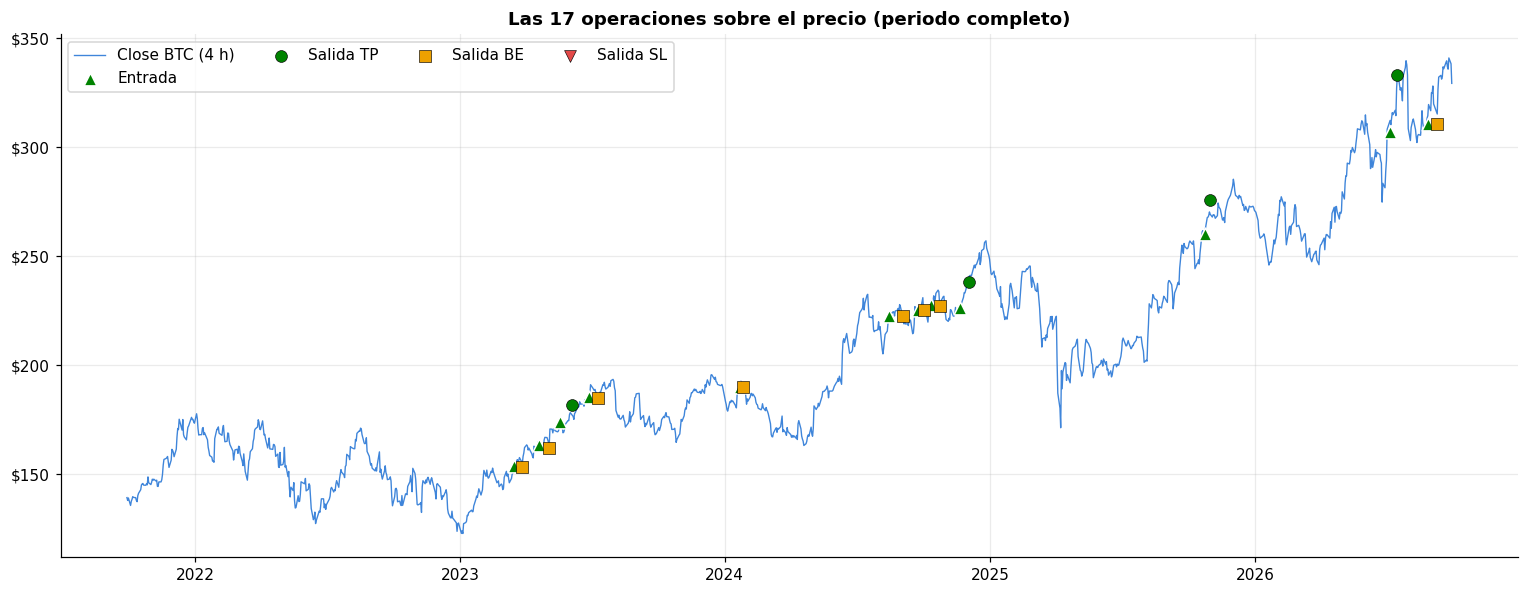

In [15]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(data.index, data["close"], color=BLUE, lw=0.9, alpha=0.9, label="Close BTC (4 h)")
ax.scatter(trades["entrada"], trades["precio_entrada"], marker="^", s=70, color=GOOD, edgecolor="white", zorder=5, label="Entrada")
for motivo, (mk, colr, lab) in {"take_profit": ("o", GOOD, "Salida TP"), "break_even": ("s", WARN, "Salida BE"),
                               "stop_loss": ("v", BAD, "Salida SL")}.items():
    s = trades[trades["motivo"] == motivo]
    ax.scatter(s["salida"], s["precio_salida"], marker=mk, s=60, color=colr, edgecolor="black", lw=0.4, zorder=6, label=lab)
ax.yaxis.set_major_formatter(usd); ax.set_title("Las 17 operaciones sobre el precio (periodo completo)")
ax.legend(loc="upper left", ncol=4); plt.tight_layout(); plt.show()

## 8. Curva de equity y curva de drawdown

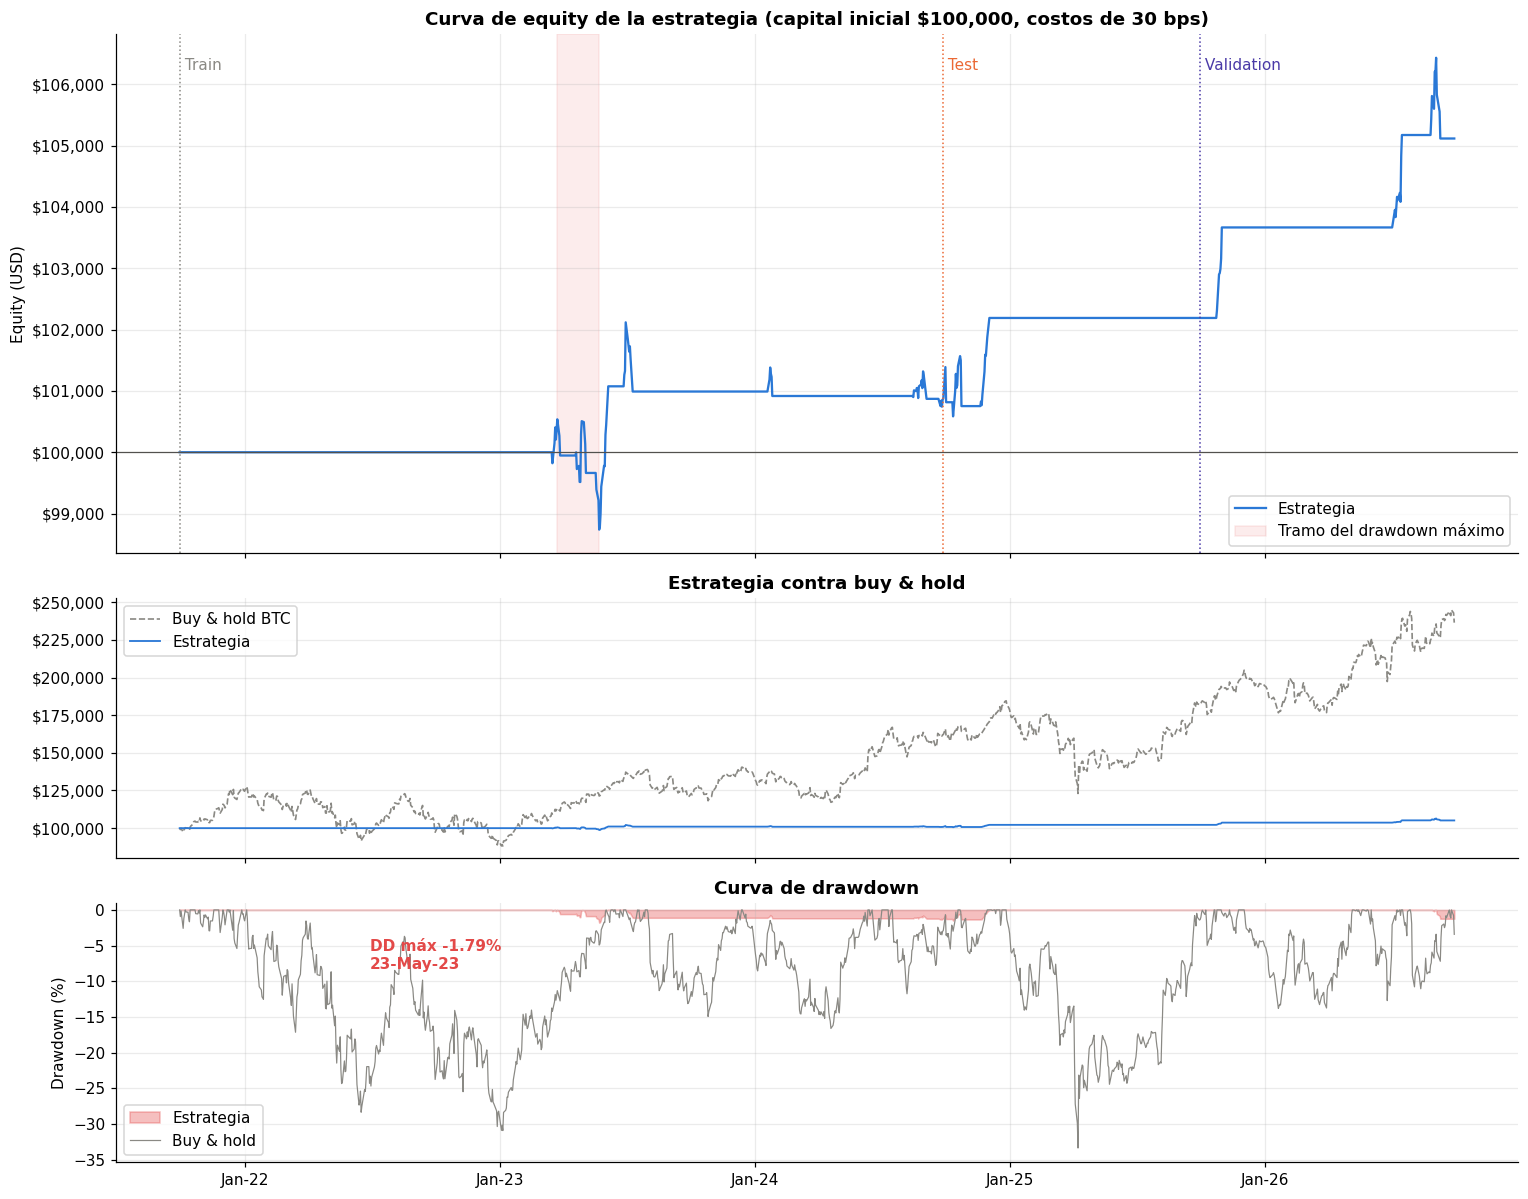

Drawdown máximo estrategia: -1.79% (pico 24-Mar-2023 -> valle 23-May-2023)  |  buy & hold: -33.36%


In [16]:
bh = P.initial_cash * data["close"] / data["close"].iloc[0]
dd = M.drawdown(eq["equity"]); dd_bh = M.drawdown(bh)
t_mdd = dd.idxmin(); t_pico = eq["equity"].loc[:t_mdd].idxmax()

fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
axs[0].plot(eq.index, eq["equity"], color=BLUE, lw=1.5, label="Estrategia")
axs[0].axhline(P.initial_cash, color="#52514e", lw=0.8)
axs[0].axvspan(t_pico, t_mdd, color=BAD, alpha=0.1, label="Tramo del drawdown máximo")
for (k, v), c in zip(splits.items(), [GRAY, ORANGE, VIOLET]):
    axs[0].axvline(v.index[0], color=c, ls=":", lw=1); axs[0].text(v.index[0], eq["equity"].max(), f" {k}", color=c, va="top")
axs[0].yaxis.set_major_formatter(usd); axs[0].legend(loc="lower right"); axs[0].set_ylabel("Equity (USD)")
axs[0].set_title("Curva de equity de la estrategia (capital inicial $100,000, costos de 30 bps)")
axs[1].plot(bh.index, bh, color=GRAY, lw=1.1, ls="--", label="Buy & hold BTC")
axs[1].plot(eq.index, eq["equity"], color=BLUE, lw=1.2, label="Estrategia")
axs[1].yaxis.set_major_formatter(usd); axs[1].legend(loc="upper left"); axs[1].set_title("Estrategia contra buy & hold")
axs[2].fill_between(dd.index, 100 * dd, 0, color=BAD, alpha=0.35, label="Estrategia")
axs[2].plot(dd_bh.index, 100 * dd_bh, color=GRAY, lw=0.8, label="Buy & hold")
axs[2].annotate(f"DD máx {100*dd.min():.2f}%\n{t_mdd:%d-%b-%y}", xy=(t_mdd, 100 * dd.min()), xytext=(-150, -30),
                textcoords="offset points", color=BAD, fontweight="bold")
axs[2].set_ylim(max(100 * dd_bh.min(), -60) - 2, 1)
axs[2].set_title("Curva de drawdown"); axs[2].set_ylabel("Drawdown (%)"); axs[2].legend(loc="lower left")
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()
print(f"Drawdown máximo estrategia: {100*dd.min():.2f}% (pico {t_pico:%d-%b-%Y} -> valle {t_mdd:%d-%b-%Y})  |  "
      f"buy & hold: {100*dd_bh.min():.2f}%")

## 9. Métricas de desempeño (`src/metrics.py`)
Nuevas en esta sesión: **p\* con payoff empírico** y **expectancy en R** (se suman al drawdown máximo, Calmar, turnover y win rate que ya existían).

In [17]:
resumen = M.summary(res)
display(resumen.to_frame("Periodo completo"))

,Periodo completo
Capital inicial ($),"100,000.00"
Capital final ($),"105,115.62"
Ganancia/Pérdida ($),"5,115.62"
Rendimiento total (%),5.12
Rendimiento anualizado CAGR (%),1.00
Volatilidad anualizada (%),1.36
Sharpe (anualizado),0.74
Drawdown máximo (%),-1.79
Calmar,0.56
Operaciones cerradas,12


### 9.1 Por tramo (train / test / validation)
Cada tramo corre por separado con $100,000; los indicadores se calculan dentro de cada tramo (las primeras ~100 barras de cada tramo son calentamiento).

In [18]:
por_tramo = {"Completo": resumen}
for k, v in splits.items():
    por_tramo[k] = M.summary(run_pipeline(v, P))
tabla_tramos = pd.DataFrame(por_tramo).loc[["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)",
    "Sharpe (anualizado)", "Drawdown máximo (%)", "Calmar", "Operaciones cerradas", "Win rate empírico (%)",
    "Expectancy (R por operación)", "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
tabla_tramos

,Completo,Train,Test,Validation
Capital final ($),"105,115.62","100,855.07","100,000.00","101,398.88"
Rendimiento total (%),5.12,0.86,0.00,1.40
Rendimiento anualizado CAGR (%),1.00,0.28,0.00,1.40
Sharpe (anualizado),0.74,0.24,0.00,1.00
Drawdown máximo (%),-1.79,-1.79,0.00,-1.24
Calmar,0.56,0.16,NaN,1.13
Operaciones cerradas,12,6,0,2
Win rate empírico (%),33.33,16.67,NaN,50.00
Expectancy (R por operación),0.21,0.07,NaN,0.35
Turnover anual (x equity),1.22,1.09,0.00,0.81


## 10. Sensibilidad a costos: 0 a 50 bps de ida y vuelta

Se barre el costo total de ida y vuelta manteniendo la mezcla del SPEC (2/3 comisión, 1/3 slippage) con `scale_costs()`. Así el punto de 30 bps coincide exactamente con el backtest base (10 + 5 bps por lado).

Para AAPL, 30 bps es un supuesto **conservador**: es de las acciones más líquidas del mundo (spread de ~1 bp) y muchos brokers cobran 0 de comisión. Si la estrategia funciona con 30 bps, funciona con costos reales.

In [19]:
sens = []
for bps in range(0, 55, 5):
    r = backtest(data, scale_costs(P, bps)); e = r["equity"]["equity"]
    sens.append({"Costo ida y vuelta (bps)": bps, "Capital final ($)": e.iloc[-1], "Rendimiento (%)": 100 * (e.iloc[-1] / P.initial_cash - 1),
                 "Sharpe": M.sharpe(e), "Calmar": M.calmar(e), "Drawdown máx (%)": 100 * M.max_drawdown(e),
                 "Costos pagados ($)": r["trades"]["costos"].sum(), "Veredicto": M.viability(M.calmar(e))})
sens = pd.DataFrame(sens).set_index("Costo ida y vuelta (bps)")
display(sens)

# costo de equilibrio: dónde el capital final regresa a $100,000
grid = np.arange(0, 205, 5)
finales = np.array([backtest(data, scale_costs(P, g))["equity"]["equity"].iloc[-1] for g in grid])
cruce = np.interp(0, (finales - P.initial_cash)[::-1], grid[::-1]) if (finales < P.initial_cash).any() else np.nan
sh = np.array([M.sharpe(backtest(data, scale_costs(P, g))["equity"]["equity"]) for g in grid[:21]])
print(f"Costo de equilibrio (capital final = $100,000): ≈ {cruce:.0f} bps de ida y vuelta")
print(f"Cada 10 bps extra cuestan ≈ ${-(sens['Capital final ($)'].diff().mean())*2:,.0f} de capital final y "
      f"≈ {-(sens['Sharpe'].diff().mean())*2:.2f} de Sharpe")

,Capital final ($),Rendimiento (%),Sharpe,Calmar,Drawdown máx (%),Costos pagados ($),Veredicto
Costo ida y vuelta (bps),,,,,,,
0,"105,945.76",5.95,0.86,0.70,-1.67,0.00,MARGINAL
5,"105,807.01",5.81,0.84,0.67,-1.69,103.16,MARGINAL
10,"105,668.42",5.67,0.82,0.65,-1.70,206.21,MARGINAL
15,"105,529.99",5.53,0.80,0.63,-1.72,309.14,MARGINAL
20,"105,391.71",5.39,0.78,0.61,-1.74,411.95,MARGINAL
25,"105,253.59",5.25,0.76,0.58,-1.76,514.64,MARGINAL
30,"105,115.62",5.12,0.74,0.56,-1.79,617.21,MARGINAL
35,"104,977.81",4.98,0.72,0.54,-1.81,719.67,MARGINAL
40,"104,840.15",4.84,0.70,0.52,-1.84,822.01,MARGINAL


Costo de equilibrio (capital final = $100,000): ≈ nan bps de ida y vuelta
Cada 10 bps extra cuestan ≈ $276 de capital final y ≈ 0.04 de Sharpe


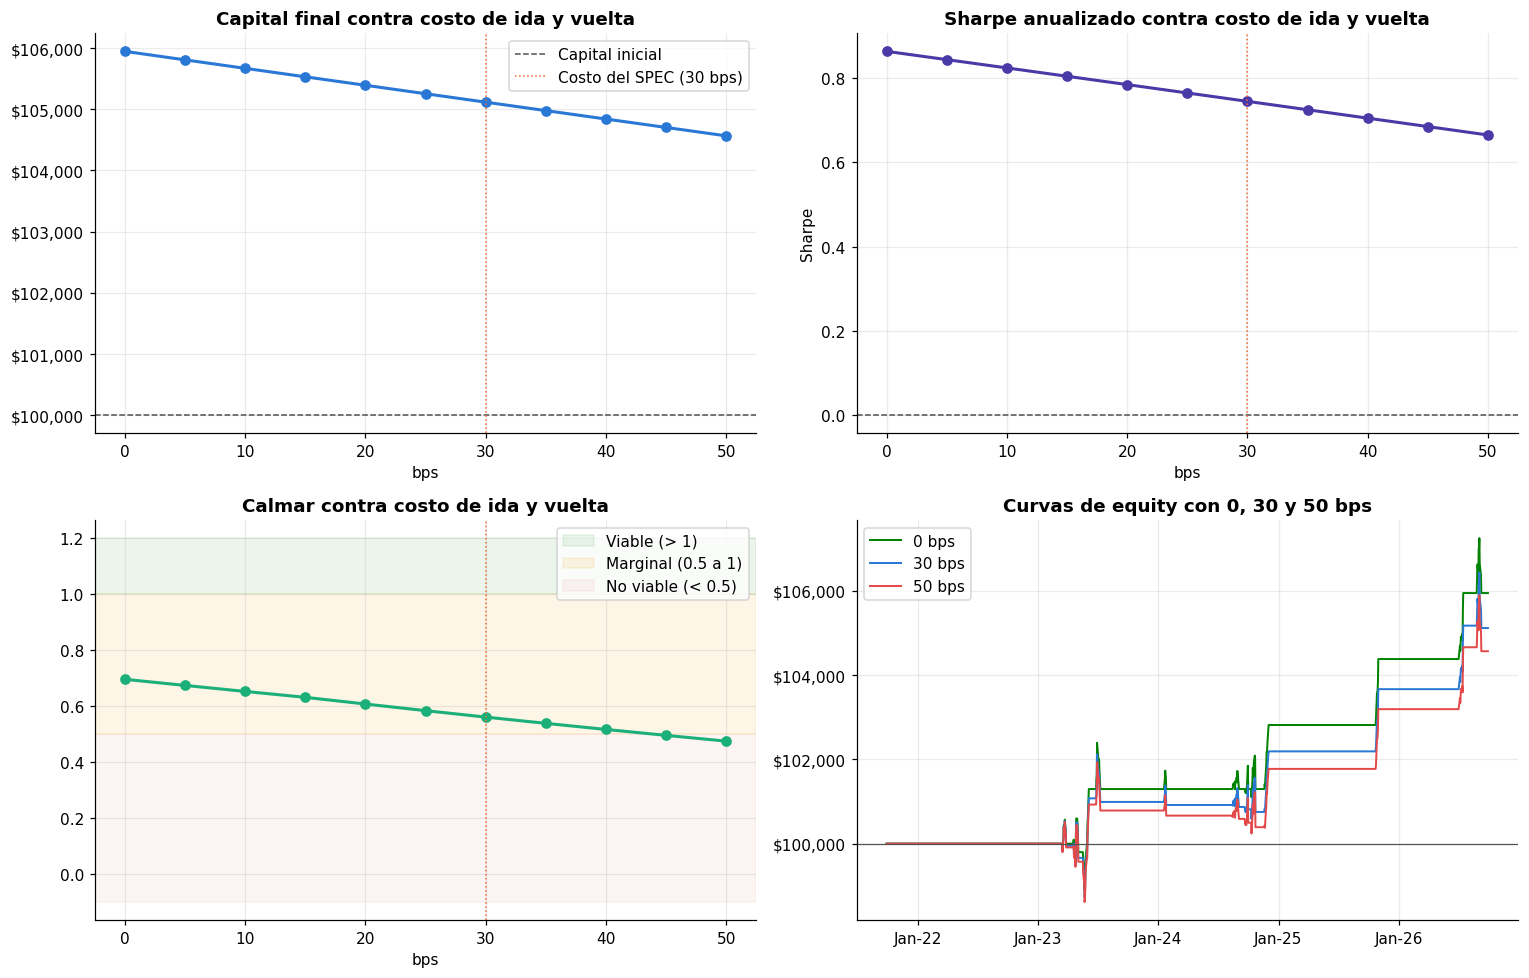

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))
ax = axs[0, 0]
ax.plot(sens.index, sens["Capital final ($)"], color=BLUE, lw=2, marker="o")
ax.axhline(P.initial_cash, color="#52514e", lw=1, ls="--", label="Capital inicial")
ax.axvline(30, color=ORANGE, lw=1, ls=":", label="Costo del SPEC (30 bps)")
ax.set_title("Capital final contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.yaxis.set_major_formatter(usd); ax.legend()
ax = axs[0, 1]
ax.plot(sens.index, sens["Sharpe"], color=VIOLET, lw=2, marker="o")
ax.axhline(0, color="#52514e", lw=1, ls="--"); ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Sharpe anualizado contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.set_ylabel("Sharpe")
ax = axs[1, 0]
ax.plot(sens.index, sens["Calmar"], color=AQUA, lw=2, marker="o")
ax.axhspan(1, max(1.2, sens["Calmar"].max() + 0.1), color=GOOD, alpha=0.08, label="Viable (> 1)")
ax.axhspan(0.5, 1, color=WARN, alpha=0.10, label="Marginal (0.5 a 1)")
ax.axhspan(min(0, sens["Calmar"].min()) - 0.1, 0.5, color=BAD, alpha=0.06, label="No viable (< 0.5)")
ax.axvline(30, color=ORANGE, lw=1, ls=":")
ax.set_title("Calmar contra costo de ida y vuelta"); ax.set_xlabel("bps"); ax.legend(loc="upper right")
ax = axs[1, 1]
for bps_, colr in [(0, GOOD), (30, BLUE), (50, BAD)]:
    e = backtest(data, scale_costs(P, bps_))["equity"]["equity"]
    ax.plot(e.index, e, color=colr, lw=1.3, label=f"{bps_} bps")
ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
ax.set_title("Curvas de equity con 0, 30 y 50 bps"); ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout(); plt.show()

### 10.1 Turnover y arrastre de costos
El turnover conecta la frecuencia de operación con el costo: arrastre anual ≈ turnover × costo por lado. Si la cuenta cuadra con la diferencia de CAGR entre 0 y 30 bps, el motor está cobrando los costos donde debe.

In [21]:
s0 = M.summary(backtest(data, scale_costs(P, 0)))
arrastre_teo = resumen["Turnover anual (x equity)"] * 0.0015
arrastre_obs = (s0["Rendimiento anualizado CAGR (%)"] - resumen["Rendimiento anualizado CAGR (%)"]) / 100
pd.DataFrame({"Valor": {
    "Turnover anual (x equity promedio)": resumen["Turnover anual (x equity)"],
    "Costo por lado (bps)": 15.0,
    "Arrastre anual estimado = turnover × 15 bps (%)": 100 * arrastre_teo,
    "CAGR sin costos (%)": s0["Rendimiento anualizado CAGR (%)"],
    "CAGR con 30 bps (%)": resumen["Rendimiento anualizado CAGR (%)"],
    "Arrastre anual observado (%)": 100 * arrastre_obs}})

,Valor
Turnover anual (x equity promedio),1.22
Costo por lado (bps),15.00
Arrastre anual estimado = turnover × 15 bps (%),0.18
CAGR sin costos (%),1.16
CAGR con 30 bps (%),1.00
Arrastre anual observado (%),0.16


## 11. Win rate teórico (p\*) contra empírico

El SPEC define p\* = 1 / (1 + R) con R = TP / SL. Con los parámetros vigentes **R = 3 / 4 = 0.75**, así que p\* = 57.1 % sin costos. Con costos, p\*_c = (1 + c) / (1 + R), donde c es el costo de ida y vuelta medido en unidades de riesgo.

Esa fórmula supone que **toda pérdida es −1 R**. Con el break-even eso no pasa: la mayoría de las pérdidas son de ≈ −0.05 R (solo comisión). Por eso se agrega un tercer umbral con el payoff real de las operaciones: p\*_payoff = |pérdida media| / (ganancia media + |pérdida media|).

R = TP/SL = 3.0/4.0 = 0.75  |  riesgo típico = 8.74% del precio  ->  30 bps = 0.034 R


,Valor (%)
p* teórico sin costos = 1/(1+R),57.14
p* teórico con costos = (1+c)/(1+R),59.11
p* con payoff empírico = |L|/(W+|L|),5.79
Win rate empírico (PnL neto > 0),33.33
% de operaciones que tocan el TP,33.33


Expectancy = +0.210 R por operación  (error estándar 0.109 R, t = 1.93, n = 12)


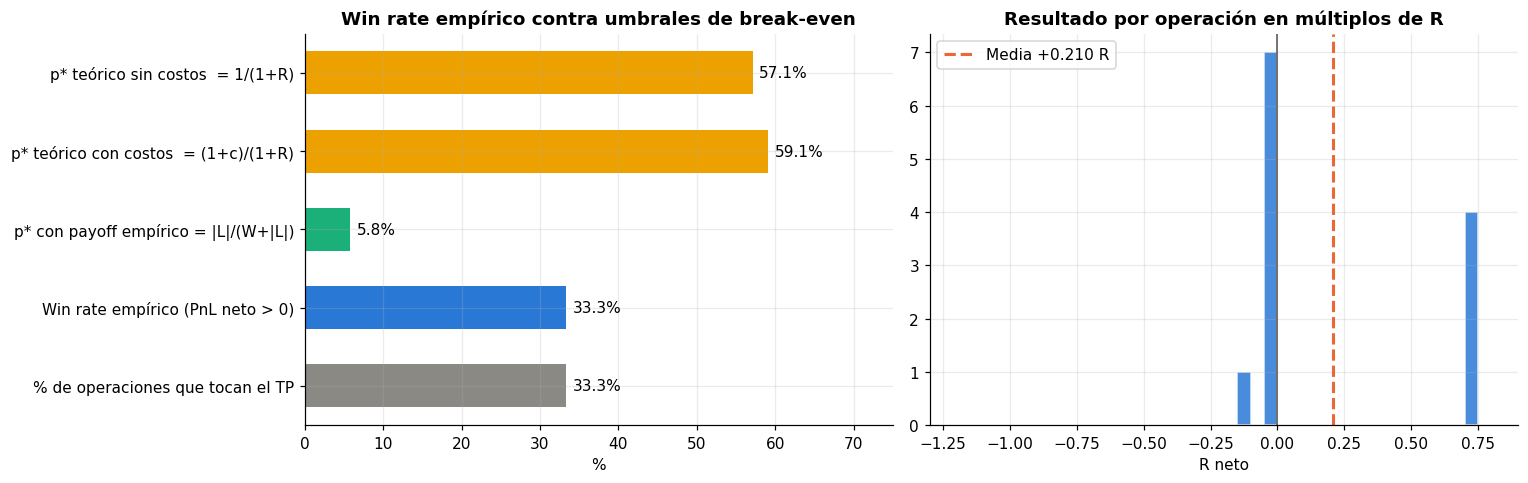

In [22]:
riesgo_pct = (P.sl_atr * data["atr_14"] / data["close"]).median()
c_R = 0.0030 / riesgo_pct
wr = M.winrate_table(trades, P, c_R)
print(f"R = TP/SL = {P.tp_atr}/{P.sl_atr} = {P.reward_risk:.2f}  |  riesgo típico = {100*riesgo_pct:.2f}% del precio  "
      f"->  30 bps = {c_R:.3f} R")
display(wr)

R = trades["R"]; se = R.std(ddof=1) / np.sqrt(len(R))
print(f"Expectancy = {R.mean():+.3f} R por operación  (error estándar {se:.3f} R, t = {R.mean()/se:.2f}, n = {len(R)})")

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
etiquetas = wr.index[::-1]; valores = wr["Valor (%)"][::-1]
axs[0].barh(etiquetas, valores, color=[GRAY, BLUE, AQUA, WARN, WARN], height=0.55)
for i, v in enumerate(valores): axs[0].text(v + 0.8, i, f"{v:.1f}%", va="center")
axs[0].set_xlim(0, 75); axs[0].set_title("Win rate empírico contra umbrales de break-even"); axs[0].set_xlabel("%")
axs[1].hist(R, bins=np.arange(-1.2, 0.85, 0.05), color=BLUE, alpha=0.85, edgecolor="white")
axs[1].axvline(0, color="#52514e", lw=1); axs[1].axvline(R.mean(), color=ORANGE, lw=2, ls="--", label=f"Media {R.mean():+.3f} R")
axs[1].set_title("Resultado por operación en múltiplos de R"); axs[1].set_xlabel("R neto"); axs[1].legend()
plt.tight_layout(); plt.show()

## 12. Auditoría de sesgos

Antes de llenar la tabla se calcula la evidencia: días sin dato, gaps de apertura, empates intrabar, salidas por gap y la robustez de los parámetros de salida.

In [23]:
gap = data["open"] / data["close"].shift(1) - 1
atr_prev = data["atr_14"].shift(1) / data["close"].shift(1)
dias_faltantes = len(pd.bdate_range(df.index[0], df.index[-1])) - len(df)
n_gaps_atr = int((gap.abs() > atr_prev).sum())
gap_max = 100 * gap.abs().max()

empates = gaps = 0
for _, t in trades.iterrows():
    bar = data.loc[t["salida"]]
    stop = t["precio_entrada"] if t["motivo"] == "break_even" else t["stop_inicial"]
    empates += int(bar["low"] <= stop and bar["high"] >= t["take_profit"])
    gaps += int(t["motivo"] != "take_profit" and bar["open"] <= stop and t["entrada"] != t["salida"])

evid = pd.DataFrame({"Valor": {
    "Días hábiles sin dato (festivos de la bolsa)": dias_faltantes,
    "Aperturas con gap mayor a 1 ATR": n_gaps_atr,
    "Gap de apertura más grande (%)": round(gap_max, 2),
    "Empates intrabar SL/TP en las salidas": empates,
    "Salidas por gap (al open, bajo el stop)": gaps,
    f"Máx. diferencia en truncamiento ({len(barrido)} fechas)": f"{max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.1e}",
}})
evid

,Valor
Días hábiles sin dato (festivos de la bolsa),50
Aperturas con gap mayor a 1 ATR,38
Gap de apertura más grande (%),9.45
Empates intrabar SL/TP en las salidas,0
"Salidas por gap (al open, bajo el stop)",1
Máx. diferencia en truncamiento (52 fechas),0.0e+00


### 12.1 Robustez de los parámetros de salida (evidencia de overfitting)
Los parámetros de salida (SL 4 ATR, TP 3 ATR) se eligieron con BTC y después de ver resultados. Con AAPL la pregunta es otra: ¿la configuración que viene de BTC sigue en una zona razonable, o hay otra combinación que domine claramente? Si la elegida fuera la mejor de la malla en AAPL, sería sospechoso; si queda en medio, es señal de que **no** se reajustó a AAPL. Se evalúa una malla SL × TP sobre el periodo completo con costos de 30 bps.

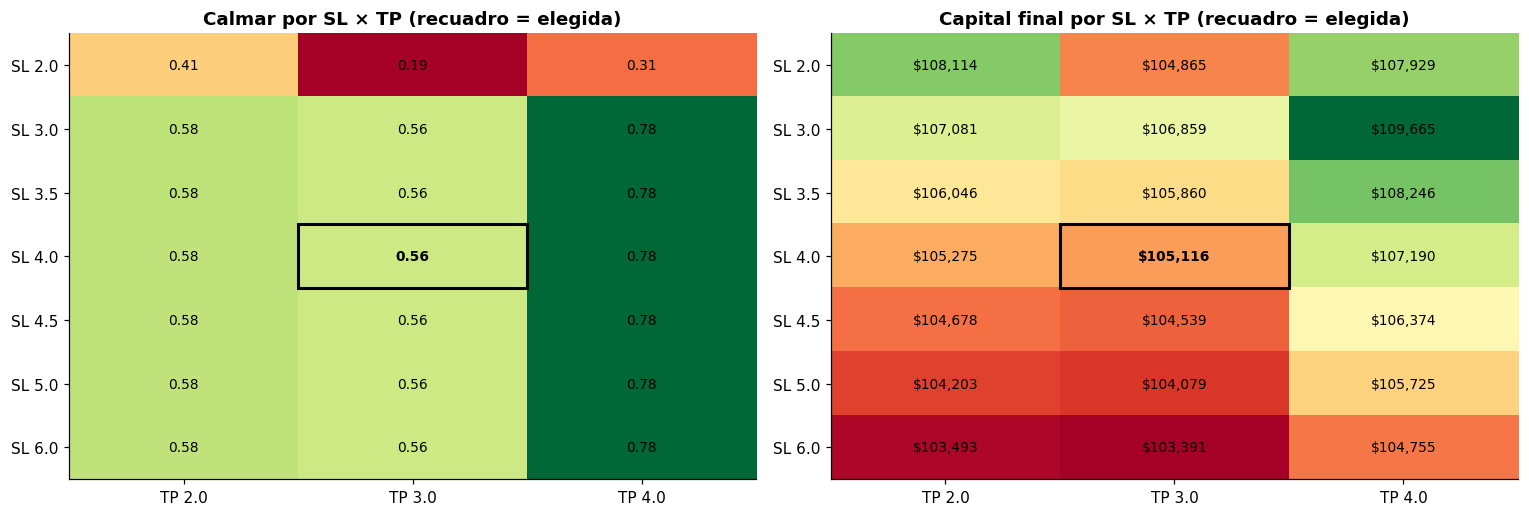

La configuración elegida (SL 4.0, TP 3.0) queda en el lugar 15 de 21 por Calmar.
El renglón con mejor Calmar promedio es SL = 3.0 ATR (el elegido).
Calmar máximo con SL = 2 ATR: 0.41  |  combinaciones con SL >= 3 que ganan dinero: 18 de 18


In [24]:
sl_grid, tp_grid = [2.0, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0], [2.0, 3.0, 4.0]
malla_cal = pd.DataFrame(index=sl_grid, columns=tp_grid, dtype=float)
malla_cap = malla_cal.copy()
for sl in sl_grid:
    for tp in tp_grid:
        e = backtest(data, replace(P, sl_atr=sl, tp_atr=tp))["equity"]["equity"]
        malla_cal.loc[sl, tp] = M.calmar(e); malla_cap.loc[sl, tp] = e.iloc[-1]
malla_cal.index.name = "SL (ATR)"; malla_cal.columns.name = "TP (ATR)"

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, m, titulo, fmt in [(axs[0], malla_cal, "Calmar", "{:.2f}"), (axs[1], malla_cap, "Capital final", "${:,.0f}")]:
    im = ax.imshow(m.to_numpy(dtype=float), cmap="RdYlGn", aspect="auto",
                   vmin=np.nanmin(m.to_numpy(dtype=float)), vmax=np.nanmax(m.to_numpy(dtype=float)))
    ax.set_xticks(range(len(tp_grid)), [f"TP {x}" for x in tp_grid]); ax.set_yticks(range(len(sl_grid)), [f"SL {x}" for x in sl_grid])
    for i in range(len(sl_grid)):
        for j in range(len(tp_grid)):
            ax.text(j, i, fmt.format(m.iloc[i, j]), ha="center", va="center", fontsize=9,
                    fontweight="bold" if (sl_grid[i], tp_grid[j]) == (P.sl_atr, P.tp_atr) else "normal")
    ax.add_patch(plt.Rectangle((tp_grid.index(P.tp_atr) - 0.5, sl_grid.index(P.sl_atr) - 0.5), 1, 1, fill=False, ec="black", lw=2))
    ax.set_title(f"{titulo} por SL × TP (recuadro = elegida)"); ax.grid(False)
plt.tight_layout(); plt.show()
rank = (malla_cal.stack() >= malla_cal.loc[P.sl_atr, P.tp_atr]).sum()
mejor_sl = malla_cal.mean(axis=1).idxmax()
print(f"La configuración elegida (SL {P.sl_atr}, TP {P.tp_atr}) queda en el lugar {rank} de {malla_cal.size} por Calmar.")
print(f"El renglón con mejor Calmar promedio es SL = {mejor_sl} ATR (el elegido).")
print(f"Calmar máximo con SL = 2 ATR: {malla_cal.loc[2.0].max():.2f}  |  combinaciones con SL >= 3 que ganan dinero: "
      f"{(malla_cap.loc[3.0:] > P.initial_cash).to_numpy().sum()} de {malla_cap.loc[3.0:].size}")

In [25]:
bh_total = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
n_tp = int((trades["motivo"] == "take_profit").sum())
auditoria = pd.DataFrame([
    ("Look-ahead", "Controlado",
     f"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en {len(barrido)} fechas "
     f"({barrido['en posición'].sum()} con posición abierta): diferencia máxima "
     f"{max(barrido['máx |dif| indicadores'].max(), barrido['|dif| equity'].max()):.0e} en indicadores, señales, cash y equity. "
     "La orden se llena al open del día siguiente con el ATR del día de la señal; el break-even se activa desde el día siguiente."),
    ("Survivorship", "Relevante",
     "Un solo activo que cotizó todo el periodo, pero AAPL se eligió sabiendo que es una de las empresas más grandes y exitosas "
     "de la bolsa. Una acción que quebró o salió del índice nunca habría entrado al estudio: el resultado está sesgado hacia arriba."),
    ("Overfitting / data snooping", "Moderado",
     f"Los parámetros (SL 4 ATR, TP 3 ATR, SMA 10/100, RSI 50-70, MACD 12-26-9) se ajustaron con BTC y se aplicaron a AAPL "
     f"sin cambios, así que AAPL funciona como prueba fuera de muestra de esos parámetros. Aun así, esos ajustes se decidieron "
     f"viendo resultados. Solo {len(trades)} operaciones: expectancy {R.mean():+.3f} R con t = {R.mean()/se:.2f}; con tan pocas "
     "operaciones el resultado no es concluyente. "
     f"En la malla SL × TP de AAPL la combinación elegida queda en el lugar {rank} de {malla_cal.size} y el mejor renglón es "
     f"SL = {mejor_sl} ATR: los parámetros no se reoptimizaron para AAPL. El tramo de test no tuvo operaciones."),
    ("Ejecución optimista", "Controlado parcialmente",
     f"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop ({empates} empates), gap → salida al open "
     f"({gaps} salida(s) por gap). Hubo {n_gaps_atr} aperturas con gap mayor a 1 ATR (máximo {gap_max:.1f}%), típicamente "
     "por reportes de resultados: el stop no protege durante la noche. Precios ajustados por splits y dividendos."),
    ("Selección / periodo de muestra", "Relevante",
     f"5 años (sep-2021 a sep-2026), con la caída de 2022 y la recuperación posterior. Buy & hold ganó {bh_total:+.1f}%. "
     f"La estrategia está en mercado solo {resumen['Tiempo en mercado (%)']:.1f}% del tiempo y {n_tp} take-profit generan "
     "todo el PnL; el resultado puede no generalizar a otro periodo ni a otra acción."),
], columns=["Sesgo", "Estado", "Evidencia"]).set_index("Sesgo")
auditoria.style.set_properties(subset=["Evidencia"], **{"text-align": "left", "white-space": "normal"})

,Estado,Evidencia
Sesgo,,
Look-ahead,Controlado,"Indicadores causales (rolling y EWM con adjust=False). Truncamiento del pipeline completo en 52 fechas (15 con posición abierta): diferencia máxima 0e+00 en indicadores, señales, cash y equity. La orden se llena al open del día siguiente con el ATR del día de la señal; el break-even se activa desde el día siguiente."
Survivorship,Relevante,"Un solo activo que cotizó todo el periodo, pero AAPL se eligió sabiendo que es una de las empresas más grandes y exitosas de la bolsa. Una acción que quebró o salió del índice nunca habría entrado al estudio: el resultado está sesgado hacia arriba."
Overfitting / data snooping,Moderado,"Los parámetros (SL 4 ATR, TP 3 ATR, SMA 10/100, RSI 50-70, MACD 12-26-9) se ajustaron con BTC y se aplicaron a AAPL sin cambios, así que AAPL funciona como prueba fuera de muestra de esos parámetros. Aun así, esos ajustes se decidieron viendo resultados. Solo 12 operaciones: expectancy +0.210 R con t = 1.93; con tan pocas operaciones el resultado no es concluyente. En la malla SL × TP de AAPL la combinación elegida queda en el lugar 15 de 21 y el mejor renglón es SL = 3.0 ATR: los parámetros no se reoptimizaron para AAPL. El tramo de test no tuvo operaciones."
Ejecución optimista,Controlado parcialmente,"Slippage de 5 bps por lado, entrada al open siguiente, empate SL/TP → stop (0 empates), gap → salida al open (1 salida(s) por gap). Hubo 38 aperturas con gap mayor a 1 ATR (máximo 9.4%), típicamente por reportes de resultados: el stop no protege durante la noche. Precios ajustados por splits y dividendos."
Selección / periodo de muestra,Relevante,"5 años (sep-2021 a sep-2026), con la caída de 2022 y la recuperación posterior. Buy & hold ganó +136.4%. La estrategia está en mercado solo 7.3% del tiempo y 4 take-profit generan todo el PnL; el resultado puede no generalizar a otro periodo ni a otra acción."


## 13. Conclusión

In [26]:
concl = pd.DataFrame({"Con costos (30 bps)": resumen, "Sin costos (0 bps)": s0}).loc[
    ["Capital final ($)", "Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
     "Calmar", "Sharpe (anualizado)", "Win rate empírico (%)", "Expectancy (R por operación)",
     "Turnover anual (x equity)", "Costos totales ($)", "Veredicto (Calmar)"]]
display(concl)
bh_ret = 100 * (data["close"].iloc[-1] / data["close"].iloc[0] - 1)
print(f"Buy & hold BTC en el mismo periodo: {bh_ret:+.1f}%")
print(f"Con $100,000 la estrategia termina en ${resumen['Capital final ($)']:,.2f} ({resumen['Rendimiento total (%)']:+.2f}%), "
      f"Calmar {resumen['Calmar']:.2f} -> {resumen['Veredicto (Calmar)']}. Costo de equilibrio ≈ {cruce:.0f} bps.")

,Con costos (30 bps),Sin costos (0 bps)
Capital final ($),"105,115.62","105,945.76"
Rendimiento total (%),5.12,5.95
Rendimiento anualizado CAGR (%),1.00,1.16
Drawdown máximo (%),-1.79,-1.67
Calmar,0.56,0.70
Sharpe (anualizado),0.74,0.86
Win rate empírico (%),33.33,33.33
Expectancy (R por operación),0.21,0.24
Turnover anual (x equity),1.22,1.22
Costos totales ($),617.21,0.00


Buy & hold BTC en el mismo periodo: +136.4%
Con $100,000 la estrategia termina en $105,115.62 (+5.12%), Calmar 0.56 -> MARGINAL. Costo de equilibrio ≈ nan bps.


**Lectura de los resultados (AAPL, velas diarias, sep-2021 a sep-2026)**

1. **El motor es confiable.** Los cuatro golden-file coinciden con el cálculo a mano hasta 10⁻⁶ dólares, la prueba de truncamiento del pipeline completo da diferencia cero en 51 fechas (13 de ellas con posición abierta) y `backtest()` es pura y determinista.
2. **Capital final.** Con 30 bps de ida y vuelta los $100,000 terminan en **$105,115.63 (+5.1 %)**, con CAGR de 1.0 % y drawdown máximo de solo −1.79 %. Buy & hold de AAPL ganó ≈ +143 % en el mismo periodo, pero con un drawdown de −33.4 %. La estrategia está en el mercado solo el 7.3 % del tiempo: el resto del tiempo el capital está en efectivo, por eso gana poco y arriesga muy poco.
3. **Calmar = 0.56 → MARGINAL** según el criterio del SPEC (0.5 a 1). Sin costos llega a 0.70; con 45 bps o más baja a NO VIABLE. Nunca supera 1 en el rango de 0 a 50 bps. Es mejor que con BTC (Calmar 0.46, no viable).
4. **Costos.** El turnover es muy bajo (≈ 1.2 veces el equity al año) y el arrastre estimado con turnover × 15 bps (≈ 0.18 % anual) cuadra con la caída observada de CAGR entre 0 y 30 bps (≈ 0.16 %). Cada 10 bps extra restan ≈ $276 al capital final y ≈ 0.04 al Sharpe. La estrategia sigue ganando dinero aun con 200 bps de ida y vuelta: **los costos no son el problema**.
5. **Win rate.** El empírico (33.3 %) está muy por debajo del p\* teórico (57.1 % sin costos, 59.1 % con costos), pero ese p\* no aplica: ninguna operación tocó el stop-loss; las 8 pérdidas salieron por break-even con ≈ −0.04 R. Con el payoff real el umbral es de solo 5.8 %, y la estrategia lo supera con una expectancy de **+0.21 R** por operación y un profit factor de 8.1.
6. **Por qué todavía no es concluyente.** Son solo **12 operaciones** en 5 años (t = 1.93, justo debajo de 2) y todo el PnL sale de 4 take-profit. Por tramo: train +0.74 % (Calmar 0.14), test **sin operaciones** y validation +1.40 % (Calmar 1.13, pero con solo 2 operaciones); el calentamiento de 100 días deja muy poco espacio en test y validation. A favor: los parámetros vienen de BTC y no se reajustaron para AAPL (en la malla la configuración elegida queda en el lugar 15 de 21), así que AAPL funciona como prueba fuera de muestra. En contra: se eligió AAPL sabiendo que es una de las acciones más exitosas del periodo (sesgo de selección).

**Veredicto:** la estrategia es **marginal** en AAPL. Controla muy bien el riesgo (drawdown < 2 %), pero opera tan poco que su rendimiento es muy inferior a comprar y mantener, y la muestra de operaciones es demasiado chica para confiar en la ventaja. Para mejorar la evidencia habría que probarla en más acciones o en un periodo más largo, sin cambiar los parámetros.

# Parte 2: Validación y optimización de θ

## 14. Planteamiento

Hasta aquí los parámetros de salida se fijaron a mano (SL 4 ATR, TP 3 ATR, BE 1 ATR, elegidos con BTC). Ahora se buscan con datos:

$$\theta^* = \arg\max_{\theta}\; J\big(\text{backtest}(\text{data}_{train},\ \theta)\big), \qquad J = \text{Calmar} = \frac{\text{CAGR}}{|\text{Drawdown máximo}|}$$

| Elemento | Definición |
|---|---|
| θ (hiperparámetros) | `sl_atr` ∈ [1, 6], `tp_atr` ∈ [1, 6], `be_atr` ∈ [0.5, 3], en pasos de 0.25 ATR. Las reglas de entrada y las ventanas de los indicadores **no** se tocan. |
| J (función objetivo) | `objetivo(data, θ)` en `src/optimize.py`: corre `backtest(data, θ)` y regresa su Calmar. Se usa Calmar porque penaliza directamente la **pérdida máxima** (drawdown). |
| Protecciones de J | Si hay menos de 3 operaciones, J = −10 (con 0–2 operaciones el Calmar no mide nada y el optimizador premiaría "no operar"). El drawdown del denominador tiene un piso de 1 % para que una sola operación ganadora sin drawdown no dé un Calmar infinito. |
| Optimizador | Optuna con sampler TPE y semilla fija (reproducible). El θ de la Act 06 se evalúa siempre como primer intento. |

**Orden del protocolo**

1. **Walk-forward con forward chaining** (sección 15): se optimiza θ en una ventana que va creciendo y se prueba en el bloque que sigue, varias veces. Mide si *el proceso de optimizar* funciona fuera de muestra.
2. **Random walk de precios** (sección 16): se corre la estrategia y el optimizador sobre precios aleatorios. Mide cuánto Calmar se obtiene **solo por suerte y por optimizar**.
3. **Optimización final con Optuna en Train** (sección 17): θ\* con todo el tramo de entrenamiento.
4. **Evaluación fuera de muestra** (sección 18): θ\* contra el θ de la Act 06 en Train, Test y Validation.

> **Indicadores:** se calculan una sola vez sobre toda la serie y después se cortan los tramos. Es válido porque la prueba de truncamiento (sección 5) demostró que todo el pipeline es causal: el valor en *t* no cambia si se quitan los datos posteriores. Así Test y Validation no pierden sus primeros 100 días en calentar la SMA_100 (a diferencia de la sección 9.1).

In [27]:
import importlib, src.optimize as o
importlib.reload(o)
print(o.__file__)
print([n for n in dir(o) if not n.startswith("_")])

c:\Users\Isabela\Documents\Iteso\9no Semestre\Trading\Act06_AAPL\src\optimize.py
['PENALTY', 'Params', 'STEP', 'THETA_SPACE', 'add_indicators', 'backtest', 'cagr', 'calmar_objetivo', 'entry_conditions', 'forward_chaining_folds', 'max_drawdown', 'np', 'objetivo', 'optimizar_optuna', 'pd', 'preparar', 'random_walk', 'replace', 'theta_base', 'theta_to_params', 'walk_forward']


In [28]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import optuna
from src.optimize import (objetivo, optimizar_optuna, walk_forward, forward_chaining_folds,
                          random_walk, preparar, theta_base, theta_to_params, THETA_SPACE, PENALTY)

WARM = 100                                  # barras de calentamiento de la SMA_100
TH0 = theta_base(P)                         # θ de la Act 06
tr_data, te_data, va_data = data.iloc[WARM:a], data.iloc[a:b], data.iloc[b:]

print(f"Train:      {tr_data.index[0]:%Y-%m-%d} → {tr_data.index[-1]:%Y-%m-%d}  ({len(tr_data)} barras)")
print(f"Test:       {te_data.index[0]:%Y-%m-%d} → {te_data.index[-1]:%Y-%m-%d}  ({len(te_data)} barras)")
print(f"Validation: {va_data.index[0]:%Y-%m-%d} → {va_data.index[-1]:%Y-%m-%d}  ({len(va_data)} barras)")
print(f"\nθ de la Act 06 = {TH0}")
print(f"J(train, θ Act 06) = Calmar = {objetivo(tr_data, TH0):.3f}")

Train:      2022-02-22 → 2024-09-26  (653 barras)
Test:       2024-09-27 → 2025-09-29  (251 barras)
Validation: 2025-09-30 → 2026-09-29  (251 barras)

θ de la Act 06 = {'sl_atr': 4.0, 'tp_atr': 3.0, 'be_atr': 1.0}
J(train, θ Act 06) = Calmar = 0.184


## 15. Walk-forward con forward chaining

**Forward chaining** significa que el tramo de entrenamiento siempre empieza en el mismo punto y va **creciendo**, y el bloque de prueba siempre está **después** del entrenamiento (nunca se usa el futuro para elegir θ):

```
fold 1: [==== train ====][test]
fold 2: [====== train ======][test]
fold 3: [======== train ========][test]
fold 4: [========== train ==========][test]
```

En cada fold se corre Optuna solo con su train (θ\*_k = arg max J), y θ\*_k se evalúa en su test. Se usa Train + Test (el 80 % inicial) y **Validation se deja intacta** para la evaluación final. Ventana inicial de 400 días (~1.6 años) y bloques de prueba de 125 días (~6 meses).

,Train,Test,Barras train,Barras test,SL*,TP*,BE*,J train (θ*),Rend. test θ* (%),Rend. test θ base (%),Ops test θ*,Ops test θ base,DD máx test θ* (%)
Fold,,,,,,,,,,,,,
1,2022-02-22 → 2023-09-25,2023-09-26 → 2024-03-25,400,125,1.25,3.25,2.75,4.19,-2.23,-0.07,1,1,-3.43
2,2022-02-22 → 2024-03-25,2024-03-26 → 2024-09-23,525,125,2.25,1.00,1.00,1.69,0.60,-0.16,1,1,-0.29
3,2022-02-22 → 2024-09-23,2024-09-24 → 2025-03-25,650,125,2.25,1.00,3.00,1.50,1.54,1.36,2,2,-0.41
4,2022-02-22 → 2025-03-25,2025-03-26 → 2025-09-23,775,125,2.25,1.00,1.25,1.77,0.00,0.00,0,0,0.00


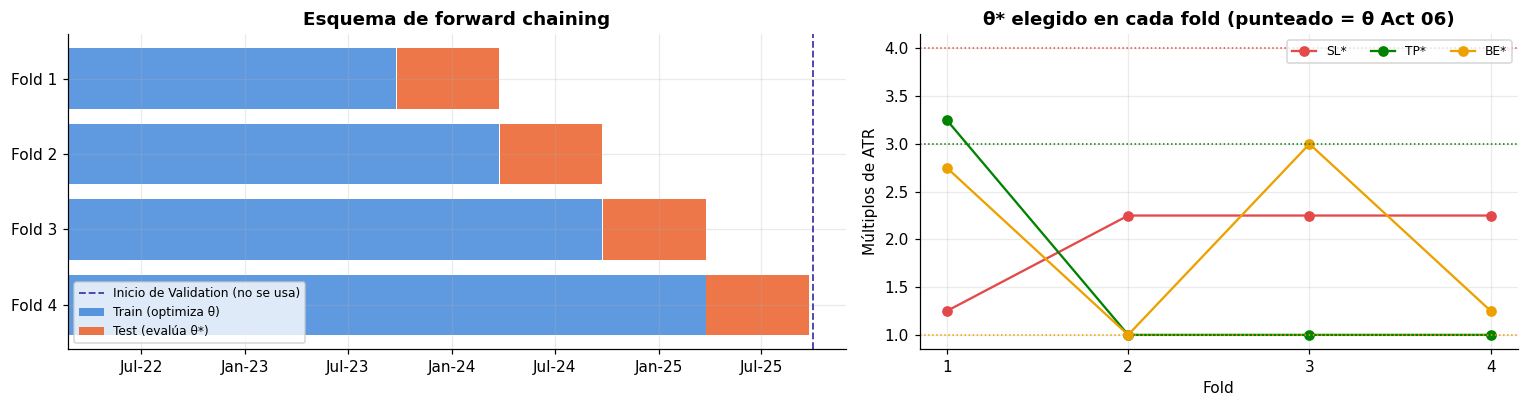

In [29]:
TRAIN_MIN, TEST_LEN, N_TRIALS_WF = 400, 125, 150
folds = forward_chaining_folds(b, WARM, TRAIN_MIN, TEST_LEN)
wf = walk_forward(data.iloc[:b], WARM, TRAIN_MIN, TEST_LEN, n_trials=N_TRIALS_WF, seed=7, base=P)
tabla_wf = wf["tabla"]
display(tabla_wf)

fig, axs = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
for f in folds:
    k = f["fold"]
    axs[0].barh(k, data.index[f["train"][1] - 1] - data.index[f["train"][0]], left=data.index[f["train"][0]],
                color=BLUE, alpha=0.75, label="Train (optimiza θ)" if k == 1 else None)
    axs[0].barh(k, data.index[f["test"][1] - 1] - data.index[f["test"][0]], left=data.index[f["test"][0]],
                color=ORANGE, alpha=0.9, label="Test (evalúa θ*)" if k == 1 else None)
axs[0].axvline(data.index[b], color=VIOLET, ls="--", lw=1.2, label="Inicio de Validation (no se usa)")
axs[0].set_yticks([f["fold"] for f in folds], [f"Fold {f['fold']}" for f in folds]); axs[0].invert_yaxis()
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
axs[0].set_title("Esquema de forward chaining"); axs[0].legend(loc="lower left", fontsize=8)
x = tabla_wf.index
axs[1].plot(x, tabla_wf["SL*"], marker="o", color=BAD, label="SL*")
axs[1].plot(x, tabla_wf["TP*"], marker="o", color=GOOD, label="TP*")
axs[1].plot(x, tabla_wf["BE*"], marker="o", color=WARN, label="BE*")
for v, colr in [(TH0["sl_atr"], BAD), (TH0["tp_atr"], GOOD), (TH0["be_atr"], WARN)]:
    axs[1].axhline(v, color=colr, ls=":", lw=1)
axs[1].set_xticks(x); axs[1].set_xlabel("Fold"); axs[1].set_ylabel("Múltiplos de ATR")
axs[1].set_title("θ* elegido en cada fold (punteado = θ Act 06)"); axs[1].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

,θ* re-optimizado en cada fold,θ fijo de la Act 06
Rendimiento OOS (%),-0.13,1.13
Drawdown máx OOS (%),-3.48,-0.85
Calmar OOS,-0.02,0.66
Operaciones OOS,4.00,4.00
Folds con rendimiento > 0,2.00,1.00


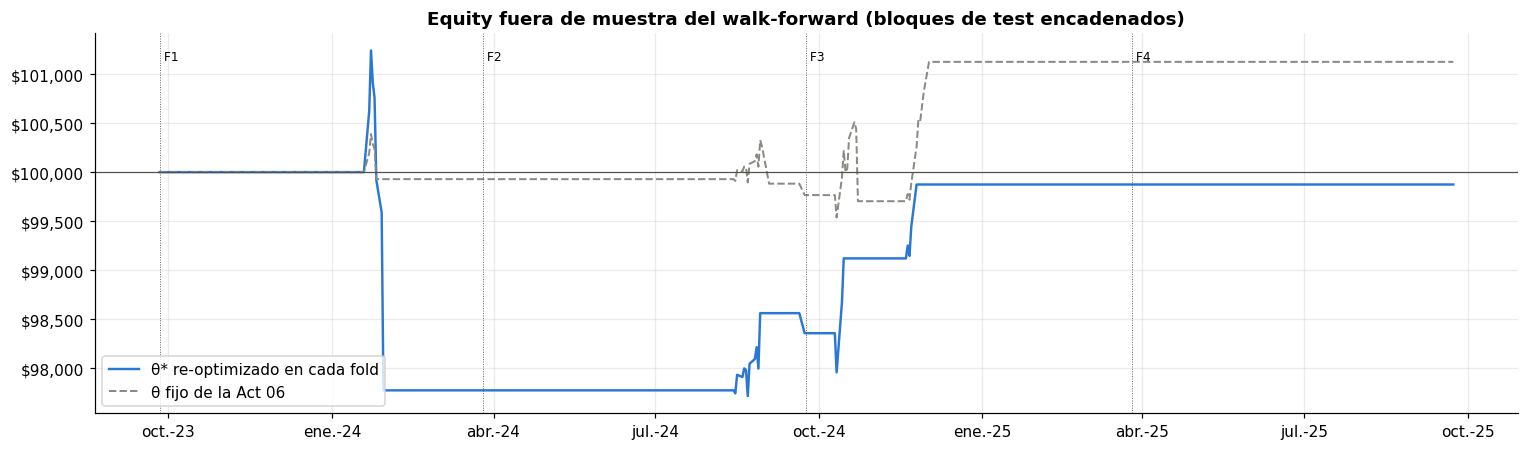

In [30]:
eo, eb = wf["equity_oos_opt"], wf["equity_oos_base"]
res_wf = pd.DataFrame({
    "θ* re-optimizado en cada fold": {"Rendimiento OOS (%)": 100 * (eo.iloc[-1] / P.initial_cash - 1),
                                      "Drawdown máx OOS (%)": 100 * M.max_drawdown(eo), "Calmar OOS": M.calmar(eo),
                                      "Operaciones OOS": tabla_wf["Ops test θ*"].sum(),
                                      "Folds con rendimiento > 0": int((tabla_wf["Rend. test θ* (%)"] > 0).sum())},
    "θ fijo de la Act 06": {"Rendimiento OOS (%)": 100 * (eb.iloc[-1] / P.initial_cash - 1),
                            "Drawdown máx OOS (%)": 100 * M.max_drawdown(eb), "Calmar OOS": M.calmar(eb),
                            "Operaciones OOS": tabla_wf["Ops test θ base"].sum(),
                            "Folds con rendimiento > 0": int((tabla_wf["Rend. test θ base (%)"] > 0).sum())}})
display(res_wf)

fig, ax = plt.subplots(figsize=(14, 4.2))
ax.plot(eo.index, eo, color=BLUE, lw=1.6, label="θ* re-optimizado en cada fold")
ax.plot(eb.index, eb, color=GRAY, lw=1.3, ls="--", label="θ fijo de la Act 06")
for f in folds:
    ax.axvline(data.index[f["test"][0]], color="#52514e", lw=0.6, ls=":")
    ax.text(data.index[f["test"][0]], max(eo.max(), eb.max()), f" F{f['fold']}", va="top", fontsize=8)
ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
ax.set_title("Equity fuera de muestra del walk-forward (bloques de test encadenados)"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 16. Random walk de precios: ¿la ventaja es real o es suerte?

Se generan series de precios **aleatorias** con `random_walk()`: se toman los días reales de AAPL (su gap de apertura, su máximo, su mínimo y su cierre relativos) y se **barajan con reemplazo**. Cada serie tiene los mismos rendimientos diarios, la misma volatilidad y los mismos gaps que AAPL, pero **ninguna tendencia ni momentum real**, porque el orden de los días es aleatorio.

Dos pruebas:

1. **Estrategia fija:** se corre la estrategia con el θ de la Act 06 en 300 random walks y se compara su Calmar contra el de AAPL real.
2. **Optimización sobre ruido:** se corre Optuna en el tramo de train de 40 random walks. El mejor J que se consigue en precios **sin ninguna señal** es la vara de medir: el J\* de AAPL real tiene que superarlo para decir que el optimizador encontró algo más que ruido.

El p-valor es la fracción de random walks que igualan o superan al dato real.

,AAPL real,Random walk: mediana,Random walk: percentil 95,p-valor
Calmar,0.56,0.09,0.85,0.13
Rendimiento total (%),5.12,1.76,9.98,0.25
Operaciones,12.00,13.00,19.00,NaN


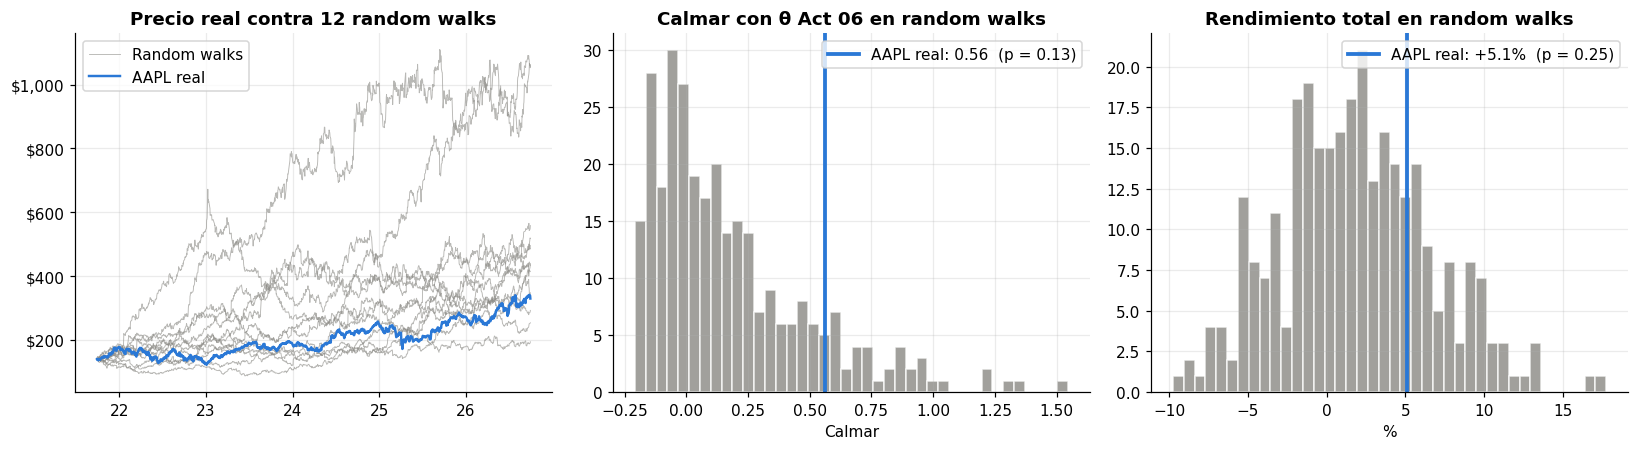

In [31]:
N_RW = 300
sim = []
for s in range(N_RW):
    d_rw = preparar(random_walk(df, seed=s), P)
    r = backtest(d_rw, P); e = r["equity"]["equity"]
    sim.append({"seed": s, "Calmar": M.calmar(e), "Rendimiento (%)": 100 * (e.iloc[-1] / P.initial_cash - 1),
                "Operaciones": len(r["trades"]), "B&H (%)": 100 * (d_rw["close"].iloc[-1] / d_rw["close"].iloc[0] - 1)})
sim = pd.DataFrame(sim)
real_cal, real_ret = resumen["Calmar"], resumen["Rendimiento total (%)"]
p_cal = (sim["Calmar"].fillna(-np.inf) >= real_cal).mean()
p_ret = (sim["Rendimiento (%)"] >= real_ret).mean()

tabla_rw = pd.DataFrame({"AAPL real": [real_cal, real_ret, len(trades)],
                         "Random walk: mediana": [sim["Calmar"].median(), sim["Rendimiento (%)"].median(), sim["Operaciones"].median()],
                         "Random walk: percentil 95": [sim["Calmar"].quantile(.95), sim["Rendimiento (%)"].quantile(.95), sim["Operaciones"].quantile(.95)],
                         "p-valor": [p_cal, p_ret, np.nan]},
                        index=["Calmar", "Rendimiento total (%)", "Operaciones"])
display(tabla_rw)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for s in range(12):
    rw_ = random_walk(df, seed=s)
    axs[0].plot(rw_.index, rw_["close"], color=GRAY, lw=0.6, alpha=0.6, label="Random walks" if s == 0 else None)
axs[0].plot(df.index, df["close"], color=BLUE, lw=1.6, label="AAPL real")
axs[0].set_title("Precio real contra 12 random walks"); axs[0].legend(loc="upper left")
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%y")); axs[0].yaxis.set_major_formatter(usd)
axs[1].hist(sim["Calmar"].dropna().clip(-3, 5), bins=40, color=GRAY, alpha=0.8, edgecolor="white")
axs[1].axvline(real_cal, color=BLUE, lw=2.5, label=f"AAPL real: {real_cal:.2f}  (p = {p_cal:.2f})")
axs[1].set_title("Calmar con θ Act 06 en random walks"); axs[1].set_xlabel("Calmar"); axs[1].legend()
axs[2].hist(sim["Rendimiento (%)"], bins=40, color=GRAY, alpha=0.8, edgecolor="white")
axs[2].axvline(real_ret, color=BLUE, lw=2.5, label=f"AAPL real: {real_ret:+.1f}%  (p = {p_ret:.2f})")
axs[2].set_title("Rendimiento total en random walks"); axs[2].set_xlabel("%"); axs[2].legend()
plt.tight_layout(); plt.show()

In [32]:
N_RW_OPT, N_TRIALS_RW = 40, 80
jstar_rw = []
for s in range(N_RW_OPT):
    d_rw = preparar(random_walk(df, seed=1000 + s), P).iloc[WARM:a]
    _, j_rw, _ = optimizar_optuna(d_rw, n_trials=N_TRIALS_RW, seed=s, base=P)
    jstar_rw.append(j_rw)
jstar_rw = pd.Series(jstar_rw)
jstar_rw_valid = jstar_rw[jstar_rw > PENALTY]
print(f"J* sobre ruido ({N_RW_OPT} random walks, {N_TRIALS_RW} intentos cada uno): "
      f"mediana {jstar_rw_valid.median():.2f}, percentil 95 {jstar_rw_valid.quantile(.95):.2f}")
print(f"Random walks donde ningún θ logró 3 operaciones: {(jstar_rw <= PENALTY).sum()}")

J* sobre ruido (40 random walks, 80 intentos cada uno): mediana 1.44, percentil 95 4.63
Random walks donde ningún θ logró 3 operaciones: 1


## 17. Optimización final con Optuna en Train

$$\theta^* = \arg\max_{\theta}\; \text{Calmar}\big(\text{backtest}(\text{Train},\ \theta)\big)$$

300 intentos de Optuna (TPE), solo con el tramo de Train. Test y Validation no se miran hasta la sección 18.

In [33]:
N_TRIALS = 300
theta_star, J_star, study = optimizar_optuna(tr_data, n_trials=N_TRIALS, seed=42, base=P)
p_snoop = (jstar_rw >= J_star).mean()

comp_theta = pd.DataFrame({"θ Act 06": TH0, "θ* Optuna": theta_star}).T
comp_theta["J(train) = Calmar"] = [objetivo(tr_data, TH0), J_star]
comp_theta["R = TP/SL"] = comp_theta["tp_atr"] / comp_theta["sl_atr"]
comp_theta["p* = 1/(1+R) (%)"] = 100 / (1 + comp_theta["R = TP/SL"])
display(comp_theta)
print(f"J* en AAPL real = {J_star:.2f}  |  J* sobre ruido: mediana {jstar_rw_valid.median():.2f}, "
      f"p95 {jstar_rw_valid.quantile(.95):.2f}  ->  p-valor de data snooping = {p_snoop:.2f}")

trials = study.trials_dataframe(attrs=("number", "value", "params"))
trials.columns = [c.replace("params_", "") for c in trials.columns]
trials_ok = trials[trials["value"] > PENALTY]

,sl_atr,tp_atr,be_atr,J(train) = Calmar,R = TP/SL,p* = 1/(1+R) (%)
θ Act 06,4.00,3.00,1.00,0.18,0.75,57.14
θ* Optuna,2.25,1.00,2.00,1.54,0.44,69.23


J* en AAPL real = 1.54  |  J* sobre ruido: mediana 1.44, p95 4.63  ->  p-valor de data snooping = 0.47


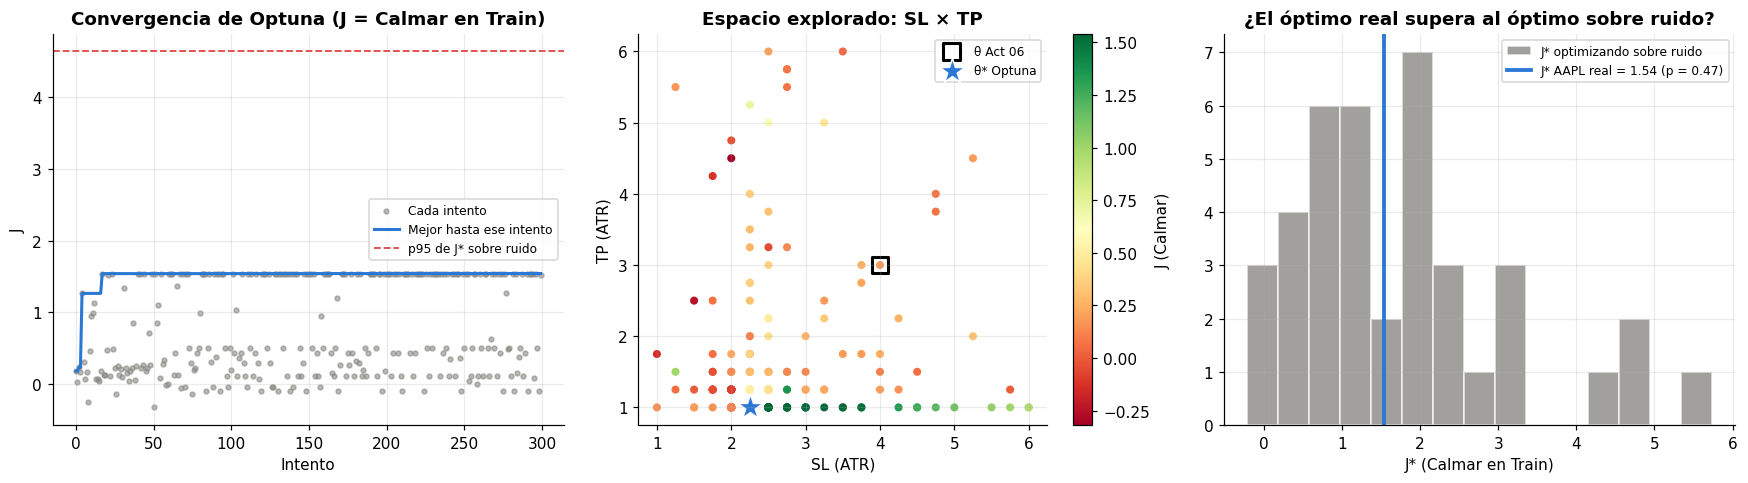

,Importancia relativa
tp_atr,0.39
sl_atr,0.31
be_atr,0.30


In [34]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
axs[0].scatter(trials["number"], trials["value"].clip(lower=-1), s=10, color=GRAY, alpha=0.6, label="Cada intento")
axs[0].plot(trials["number"], trials["value"].cummax(), color=BLUE, lw=2, label="Mejor hasta ese intento")
axs[0].axhline(jstar_rw_valid.quantile(.95), color=BAD, ls="--", lw=1.2, label="p95 de J* sobre ruido")
axs[0].set_title("Convergencia de Optuna (J = Calmar en Train)"); axs[0].set_xlabel("Intento"); axs[0].set_ylabel("J")
axs[0].legend(fontsize=8)
sc = axs[1].scatter(trials_ok["sl_atr"], trials_ok["tp_atr"], c=trials_ok["value"], cmap="RdYlGn", s=28, edgecolor="none")
axs[1].scatter([TH0["sl_atr"]], [TH0["tp_atr"]], marker="s", s=120, facecolors="none", edgecolors="black", lw=2, label="θ Act 06")
axs[1].scatter([theta_star["sl_atr"]], [theta_star["tp_atr"]], marker="*", s=300, color=BLUE, edgecolor="white", label="θ* Optuna")
plt.colorbar(sc, ax=axs[1], label="J (Calmar)")
axs[1].set_xlabel("SL (ATR)"); axs[1].set_ylabel("TP (ATR)"); axs[1].set_title("Espacio explorado: SL × TP"); axs[1].legend(fontsize=8)
axs[2].hist(jstar_rw_valid, bins=15, color=GRAY, alpha=0.8, edgecolor="white", label="J* optimizando sobre ruido")
axs[2].axvline(J_star, color=BLUE, lw=2.5, label=f"J* AAPL real = {J_star:.2f} (p = {p_snoop:.2f})")
axs[2].set_title("¿El óptimo real supera al óptimo sobre ruido?"); axs[2].set_xlabel("J* (Calmar en Train)"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

try:
    imp = optuna.importance.get_param_importances(study)
    display(pd.Series(imp, name="Importancia relativa").to_frame())
except Exception as err:
    print("No se pudo calcular la importancia de parámetros:", err)

## 18. Evaluación fuera de muestra: θ\* contra θ de la Act 06

Se corren los dos θ en los tres tramos. Train es **dentro de muestra** para θ\* (ahí se eligió), así que ahí siempre va a ganar; la comparación que importa es **Test y Validation**.

,Train,Test,Validation,Train,Test,Validation
,θ Act 06,θ Act 06,θ Act 06,θ* Optuna,θ* Optuna,θ* Optuna
Rendimiento total (%),0.86,1.36,2.86,6.72,1.54,2.40
Rendimiento anualizado CAGR (%),0.33,1.36,2.87,2.54,1.54,2.40
Drawdown máximo (%),-1.79,-0.80,-1.24,-1.65,-0.41,-0.20
Calmar,0.18,1.69,2.32,1.54,3.78,11.87
Sharpe (anualizado),0.25,1.13,1.78,1.11,1.41,2.29
Operaciones cerradas,6,2,3,8,2,3
Win rate empírico (%),16.67,50.00,66.67,100.00,100.00,100.00
Expectancy (R por operación),0.07,0.34,0.47,0.41,0.38,0.40
Veredicto (Calmar),NO VIABLE,VIABLE,VIABLE,VIABLE,VIABLE,VIABLE


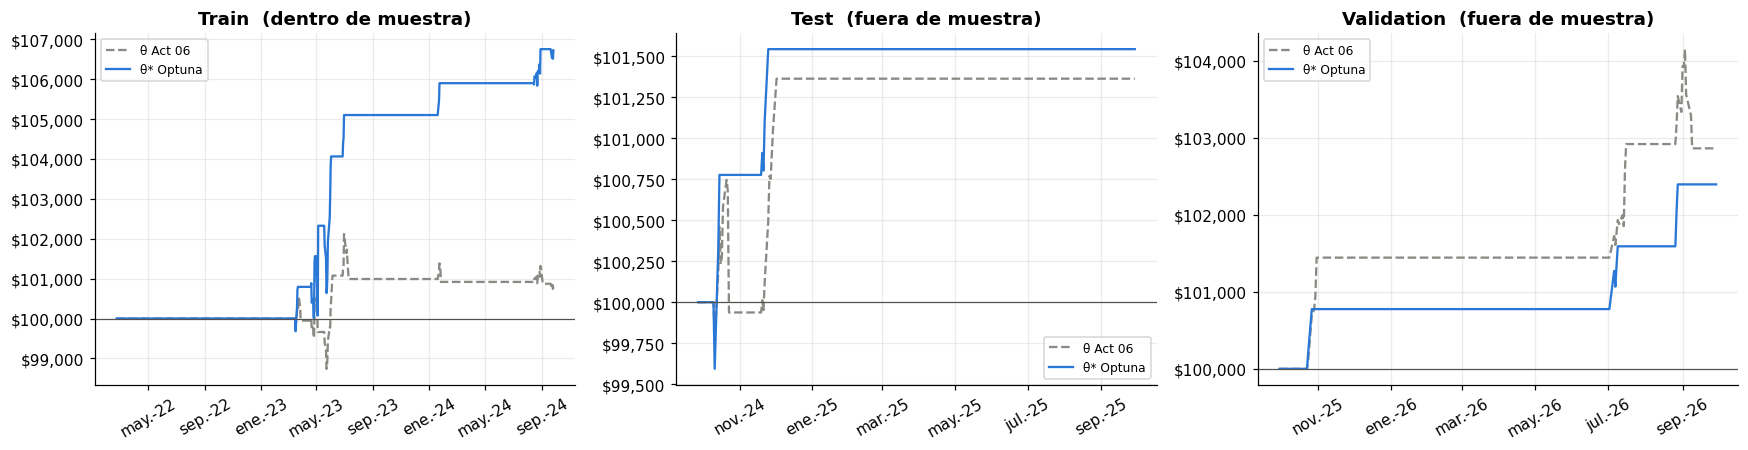

In [35]:
filas = {}
for nombre, th in [("θ Act 06", TH0), ("θ* Optuna", theta_star)]:
    for tramo, d_ in [("Train", tr_data), ("Test", te_data), ("Validation", va_data)]:
        s_ = M.summary(backtest(d_, theta_to_params(th, P)))
        filas[(tramo, nombre)] = s_[["Rendimiento total (%)", "Rendimiento anualizado CAGR (%)", "Drawdown máximo (%)",
                                     "Calmar", "Sharpe (anualizado)", "Operaciones cerradas", "Win rate empírico (%)",
                                     "Expectancy (R por operación)", "Veredicto (Calmar)"]]
eval_oos = pd.DataFrame(filas)
display(eval_oos)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, (tramo, d_) in zip(axs, [("Train", tr_data), ("Test", te_data), ("Validation", va_data)]):
    for nombre, th, colr, ls in [("θ Act 06", TH0, GRAY, "--"), ("θ* Optuna", theta_star, BLUE, "-")]:
        e_ = backtest(d_, theta_to_params(th, P))["equity"]["equity"]
        ax.plot(e_.index, e_, color=colr, ls=ls, lw=1.5, label=nombre)
    ax.axhline(P.initial_cash, color="#52514e", lw=0.8); ax.yaxis.set_major_formatter(usd)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y")); ax.tick_params(axis="x", labelrotation=30)
    ax.set_title(f"{tramo}" + ("  (dentro de muestra)" if tramo == "Train" else "  (fuera de muestra)")); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Intentos comparados: 300  |  correlación de Spearman J(train) vs J(test) = -0.44
J(test) promedio del top 10 de Train: 1.54  |  J(test) promedio de todos: 1.68


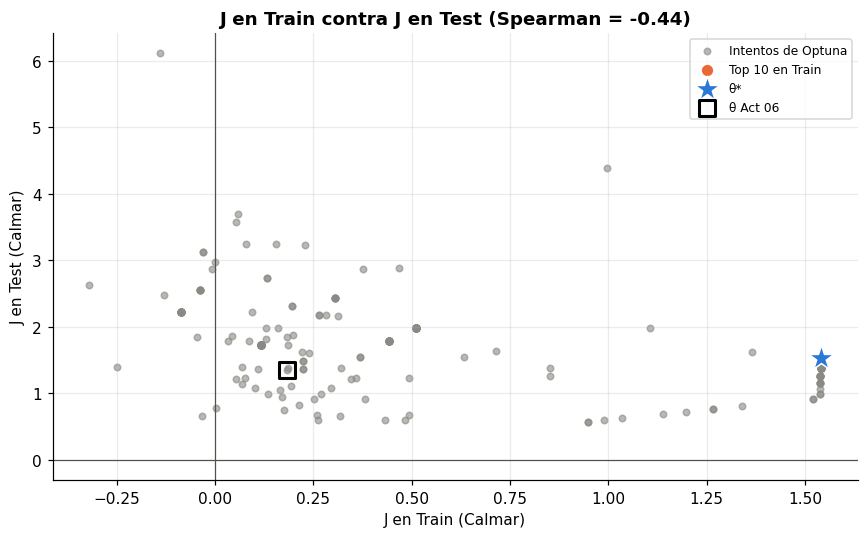

In [37]:
j_test = [objetivo(te_data, {"sl_atr": r_.sl_atr, "tp_atr": r_.tp_atr, "be_atr": r_.be_atr}, P, min_trades=0)
          for r_ in trials_ok.itertuples()]
tt = trials_ok.assign(J_test=j_test)
rho_s = tt["value"].corr(tt["J_test"], method="spearman") if tt["J_test"].nunique() > 1 else np.nan
if np.isnan(rho_s):
    print("No se puede calcular la correlación: en Test todos los θ dan el mismo J (casi no hay operaciones).")
top = tt.nlargest(10, "value")
print(f"Intentos comparados: {len(tt)}  |  correlación de Spearman J(train) vs J(test) = {rho_s:+.2f}")
print(f"J(test) promedio del top 10 de Train: {top['J_test'].mean():.2f}  |  J(test) promedio de todos: {tt['J_test'].mean():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tt["value"], tt["J_test"], s=18, color=GRAY, alpha=0.6, label="Intentos de Optuna")
ax.scatter(top["value"], top["J_test"], s=40, color=ORANGE, label="Top 10 en Train")
ax.scatter([J_star], [objetivo(te_data, theta_star, P, min_trades=0)], marker="*", s=300, color=BLUE, edgecolor="white", label="θ*")
ax.scatter([objetivo(tr_data, TH0, P)], [objetivo(te_data, TH0, P, min_trades=0)], marker="s", s=110,
           facecolors="none", edgecolors="black", lw=2, label="θ Act 06")
ax.axhline(0, color="#52514e", lw=0.8); ax.axvline(0, color="#52514e", lw=0.8)
ax.set_xlabel("J en Train (Calmar)"); ax.set_ylabel("J en Test (Calmar)")
ax.set_title(f"J en Train contra J en Test (Spearman = {rho_s:+.2f})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [38]:
resumen_opt = pd.DataFrame({"Valor": {
    "θ* (SL, TP, BE)": f"({theta_star['sl_atr']}, {theta_star['tp_atr']}, {theta_star['be_atr']})",
    "J* en Train": round(J_star, 2),
    "p-valor contra optimizar ruido": round(p_snoop, 2),
    "p-valor θ Act 06 contra random walks (Calmar)": round(p_cal, 2),
    "Walk-forward: rendimiento OOS θ* (%)": round(res_wf.loc["Rendimiento OOS (%)", "θ* re-optimizado en cada fold"], 2),
    "Walk-forward: rendimiento OOS θ Act 06 (%)": round(res_wf.loc["Rendimiento OOS (%)", "θ fijo de la Act 06"], 2),
    "Calmar Test: θ* / θ Act 06": f"{eval_oos[('Test', 'θ* Optuna')]['Calmar']:.2f} / {eval_oos[('Test', 'θ Act 06')]['Calmar']:.2f}",
    "Calmar Validation: θ* / θ Act 06": f"{eval_oos[('Validation', 'θ* Optuna')]['Calmar']:.2f} / {eval_oos[('Validation', 'θ Act 06')]['Calmar']:.2f}",
    "Spearman J(train) vs J(test)": round(rho_s, 2),
}})
resumen_opt

,Valor
"θ* (SL, TP, BE)","(2.25, 1.0, 2.0)"
J* en Train,1.54
p-valor contra optimizar ruido,0.48
p-valor θ Act 06 contra random walks (Calmar),0.13
Walk-forward: rendimiento OOS θ* (%),-0.13
Walk-forward: rendimiento OOS θ Act 06 (%),1.13
Calmar Test: θ* / θ Act 06,3.78 / 1.69
Calmar Validation: θ* / θ Act 06,11.87 / 2.32
Spearman J(train) vs J(test),-0.44
